# AutoGrow Analytics Notebook
## Complex Data Project: Growth Stage Analysis
### Advanced Analytics Pipeline: Isolation Forest → XGBoost + TimeSeriesSplit → SHAP

> **Three-Stage Intelligence Pipeline (Beyond Course)**
> 1. **Stage 1 (Isolation Forest):** Multivariate IoT anomaly detection before modelling
> 2. **Stage 2 (XGBoost + TimeSeriesSplit):** Gradient boosting with temporal cross-validation
> 3. **Stage 3 (SHAP):** Feature interpretability — *why* the model predicts each growth stage


## 1) Setup and Load 3 Tables
## 1.1 Install/Import Requirements
**Goal:** Make the notebook execution environment reproducible and ensure every dependency needed by the exploratory, preprocessing, and modeling steps is available in the current kernel.

**What we do:** Check whether the required libraries are already installed, install anything missing, and then import the full analysis stack so later cells can run without manual setup.

**Method:** Use lightweight package checks through `importlib` first, then fall back to `pip install` only when the kernel is missing a dependency. This keeps reruns faster while still making the notebook self-healing on a fresh environment.

**Why this matters:** The exhaustive notebook uses a larger toolchain than the simpler version, including imbalance handling, time-series validation, feature selection, gradient boosting, and interpretability tools. Making the environment explicit here avoids hidden failures later in the pipeline.


In [1]:
# Standard library imports
import importlib       
import subprocess      
import sys            
import os             


# Auto-installer function 
def ensure_package(pip_name, import_name=None):
    """
    Tries to import a package. If it's not found, installs it automatically via pip.
    
    - pip_name:    the name used when installing  (e.g. 'scikit-learn')
    - import_name: the name used when importing   (e.g. 'sklearn')
                   These differ for some packages, so we handle both.
    """
    module = import_name or pip_name  # Fall back to pip_name if no import_name given
    try:
        importlib.import_module(module)        # Try importing the package
    except ModuleNotFoundError:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])


# Auto-install all required packages if not already present 
ensure_package('numpy')                      
ensure_package('pandas')                      
ensure_package('matplotlib')                 
ensure_package('seaborn')                    
ensure_package('scikit-learn', 'sklearn')     
ensure_package('xgboost', 'xgboost')          
ensure_package('shap', 'shap')               
ensure_package('imbalanced-learn', 'imblearn') 


# Core data & plotting imports
import numpy as np                
import pandas as pd               
import matplotlib.pyplot as plt  
import seaborn as sns            


# Scikit-learn: evaluation metrics 
from sklearn.metrics import (
    f1_score,               
    classification_report,  
    confusion_matrix,     
    mean_absolute_error,   
    mean_squared_error,     
)

# Scikit-learn: pipeline & preprocessing 
from sklearn.pipeline import Pipeline          
from sklearn.impute import SimpleImputer       
from sklearn.preprocessing import StandardScaler  

# Scikit-learn: models 
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, IsolationForest

# Scikit-learn: model selection 
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder  
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


# Additional plotting utilities
import matplotlib.dates as mdates  
import matplotlib.patches as mpatches 


# Advanced ML libraries 
import xgboost as xgb  
import shap           
from imblearn.over_sampling import RandomOverSampler


# Global display settings 
sns.set_theme(style='whitegrid')           # Applies a clean white background to all seaborn plots
pd.set_option('display.max_columns', 200)  # Prevents pandas from hiding columns in wide DataFrames

print('Imports ready')  

Imports ready


/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2 Load Local DB Exports
**Goal:** Load the three exported database tables into memory as pandas DataFrames with stable, repeatable file-backed inputs.

**What we do:** Read the CSV exports from `data/from_db`, normalize their column names, and parse the timestamp fields that are needed for hourly alignment, lag features, and chronological splitting.

**Method:** `pandas.read_csv` plus column normalization. The notebook now operates entirely on the local exports rather than opening a live MySQL connection, which makes reruns deterministic and removes the connection-limit problem from the analysis path.

**Why this matters:** This step is the foundation for the rest of the notebook. If the raw tables are not loaded consistently, every downstream stage - merging, feature engineering, time-aware splitting, resampling, and model evaluation - becomes harder to trust.


In [2]:
import json
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen

# Local CSV exports keep notebook reruns deterministic and avoid MySQL entirely.
DATA_DIR = Path('/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/data/from_db')
CACHE_DIR = Path(os.getenv('AUTOGROW_CACHE_DIR', '/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/data/cache'))
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILES = {
    'df_autogrow': CACHE_DIR / 'df_autogrow.pkl',
    'df_outdoor_weather_current': CACHE_DIR / 'df_outdoor_weather_current.pkl',
    'df_outdoor_weather_history': CACHE_DIR / 'df_outdoor_weather_history.pkl',
}
CSV_FILES = {
    'df_autogrow': DATA_DIR / 'Autogrow.csv',
    'df_outdoor_weather_current': DATA_DIR / 'outdoor_weather_current.csv',
    'df_outdoor_weather_history': DATA_DIR / 'outdoor_weather_history.csv',
}


def _load_from_csv():
    missing = [path for path in CSV_FILES.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f'Missing local DB export files: {missing}')

    df_autogrow = pd.read_csv(CSV_FILES['df_autogrow'], parse_dates=['ts'])
    df_outdoor_weather_current = pd.read_csv(
        CSV_FILES['df_outdoor_weather_current'],
        parse_dates=['sunrise_utc', 'sunset_utc', 'fetched_at', 'stored_at'],
    )
    df_outdoor_weather_history = pd.read_csv(
        CSV_FILES['df_outdoor_weather_history'],
        parse_dates=['ts'],
    )

    for _df in [df_autogrow, df_outdoor_weather_current, df_outdoor_weather_history]:
        _df.columns = [c.strip().lower() for c in _df.columns]

    return {
        'df_autogrow': df_autogrow,
        'df_outdoor_weather_current': df_outdoor_weather_current,
        'df_outdoor_weather_history': df_outdoor_weather_history,
    }


def _save_cache(dfs):
    for key, path in CACHE_FILES.items():
        dfs[key].to_pickle(path)


dfs = _load_from_csv()
df_autogrow = dfs['df_autogrow']
df_outdoor_weather_current = dfs['df_outdoor_weather_current']
df_outdoor_weather_history = dfs['df_outdoor_weather_history']
autogrow_table = 'Autogrow (csv)'
current_table = 'outdoor_weather_current (csv)'
history_table = 'outdoor_weather_history (csv)'
_save_cache(dfs)
print(f'Loaded tables from CSV exports in {DATA_DIR}')

outdoor_lat = float(df_outdoor_weather_current['lat'].dropna().iloc[0]) if 'lat' in df_outdoor_weather_current.columns and df_outdoor_weather_current['lat'].notna().any() else 13.7563
outdoor_lon = float(df_outdoor_weather_current['lon'].dropna().iloc[0]) if 'lon' in df_outdoor_weather_current.columns and df_outdoor_weather_current['lon'].notna().any() else 100.502

def fetch_outdoor_history_range(start_date, end_date):
    """Return the local outdoor history rows within the requested date range."""
    history = df_outdoor_weather_history.copy()
    if 'ts' not in history.columns:
        return None

    history['ts'] = pd.to_datetime(history['ts'], errors='coerce')
    history = history.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)

    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date) + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    window = history[(history['ts'] >= start_ts) & (history['ts'] <= end_ts)].copy()
    return window if not window.empty else None

print('Loaded tables:')
print(f'- {autogrow_table}:', df_autogrow.shape)
print(f'- {current_table}:', df_outdoor_weather_current.shape)
print(f'- {history_table}:', df_outdoor_weather_history.shape)

Loaded tables from CSV exports in /Users/Mark/SKE/DA/AutoGrow_DataAnalytics/data/from_db
Loaded tables:
- Autogrow (csv): (1569, 16)
- outdoor_weather_current (csv): (98, 12)
- outdoor_weather_history (csv): (192, 7)


## 1.3 Preview
**Goal:** Confirm that the CSV exports were loaded correctly before any transformation or modeling begins.

**What we do:** Inspect the first few rows of each table so the notebook can verify the schema, the data types, and the general shape of the imported data.

**Method:** Display `.head()` for each source table.

**Why this matters:** A quick preview catches schema drift early. It is much better to notice missing columns, malformed timestamps, or unexpected null-heavy fields at the beginning of the notebook than after the model pipeline has already been built on bad assumptions.


In [3]:
display(df_autogrow.head())
display(df_outdoor_weather_current.head())
display(df_outdoor_weather_history.head())

,id,ts,stage,stage_name,spectrum,temp1,temp2,humidity,soil_pct,light_lux,vibration,pump_on,pump_status,light_hrs_today,harvest_eta_days,health_score
0,2,2026-04-11 17:07:39,0,Seedling,OFF,31.0,31.0,92.0,100.0,250.3,0,0,IDLE,3.18,14,80
1,3,2026-04-11 17:17:40,0,Seedling,OFF,31.0,31.0,90.0,100.0,225.9,0,0,IDLE,3.34,14,80
2,4,2026-04-11 17:27:41,0,Seedling,OFF,31.0,31.0,89.5,99.9,214.7,0,0,IDLE,3.51,14,80
3,5,2026-03-31 03:02:57,0,Seedling,OFF,45.0,0.0,45.0,45.0,45.0,0,0,OK,0.00,0,0
4,6,2026-03-31 03:04:02,0,Seedling,OFF,45.0,0.0,45.0,50.0,45.0,0,0,OK,0.00,0,0


,id,lat,lon,source,temp_c,humidity,wind_speed_mps,apparent_temp_c,sunrise_utc,sunset_utc,fetched_at,stored_at
0,1,13.7563,100.502,open-meteo,29.0,82,10.1,34.7,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 17:52:48,2026-04-20 19:04:18
1,2,13.7563,100.502,open-meteo,29.0,82,10.1,34.7,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 17:52:48,2026-04-20 19:21:50
2,3,13.7563,100.502,open-meteo,28.8,81,8.6,34.5,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 19:22:37,2026-04-20 19:22:37
3,4,13.7563,100.502,open-meteo,32.5,64,8.9,39.3,2026-04-21 06:01:00,2026-04-21 18:32:00,2026-04-21 04:16:54,2026-04-21 04:24:50
4,5,13.7563,100.502,open-meteo,32.5,64,8.9,39.3,2026-04-20 23:01:00,2026-04-21 11:32:00,2026-04-21 04:18:51,2026-04-21 04:24:50


,id,lat,lon,source,ts,temp_c,humidity
0,1,13.7563,100.502,open-meteo,2026-04-13 00:00:00,28.3,89
1,2,13.7563,100.502,open-meteo,2026-04-13 01:00:00,30.0,76
2,3,13.7563,100.502,open-meteo,2026-04-13 02:00:00,31.8,62
3,4,13.7563,100.502,open-meteo,2026-04-13 03:00:00,33.3,57
4,5,13.7563,100.502,open-meteo,2026-04-13 04:00:00,34.9,52


## 2) Complex Data Exploration
## 2.1 Detect Key Columns & Parse Timestamps
**Goal:** Standardize all three DataFrames so they share consistent sensor names, timestamp fields, and merge keys before any comparison or modeling is attempted.

**Method:** Use heuristic column detection with prioritized candidate names, then parse the chosen timestamp columns with `pd.to_datetime` and normalize them into a shared timezone-free representation.

**Processes:**
- **Column detection:** `first_existing()` searches for the first matching candidate name, so the notebook can survive small schema differences between exports.
- **Timestamp detection:** `detect_datetime_col()` scores candidate columns by parse success rate and chooses the one that most likely contains the true time index.
- **Timestamp standardization:** All timestamps are converted to UTC first and then stripped back to naive datetimes so indoor and outdoor sources can be compared directly.
- **Hour bucketing:** The timestamps are floored to hourly buckets to create a common merge key for the indoor and outdoor data streams.

**Why this matters:** The entire analysis depends on the indoor and outdoor tables being aligned on time. If timestamp parsing is wrong here, the merged dataset, rolling features, and train/test split will all be unreliable later on.


In [4]:
def first_existing(columns, candidates):
    colset = set(columns)
    for c in candidates:
        if c in colset:
            return c
    return None  # Returns None if none of the candidates exist


def detect_datetime_col(df):
    # Filter columns whose names suggest they contain datetime values
    candidates = [c for c in df.columns if any(k in c for k in ['time', 'date', 'created', 'ts'])]
    best, score = None, -1
    for c in candidates:
        parsed = pd.to_datetime(df[c], errors='coerce', utc=True)
        # Score each candidate by what fraction of its values successfully parsed as datetime
        # The column with the highest success rate wins
        s = parsed.notna().mean()
        if s > score:
            best, score = c, s
    return best

ag = df_autogrow.copy()
wh = df_outdoor_weather_history.copy()
wc = df_outdoor_weather_current.copy()

col_ts_ag = detect_datetime_col(ag)
col_ts_wh = detect_datetime_col(wh)
col_ts_wc = detect_datetime_col(wc)

# first_existing() tries each candidate name in order and returns the first one found
# — handles different naming conventions across the exported CSV schemas
col_stage_name  = first_existing(ag.columns, ['stage_name'])
col_stage       = first_existing(ag.columns, ['stage'])
col_temp_in     = first_existing(ag.columns, ['temp1', 'temperature', 'temp'])
col_hum_in      = first_existing(ag.columns, ['humidity', 'humidity1', 'rh'])
col_soil        = first_existing(ag.columns, ['soil_pct', 'soil', 'soil_moisture'])
col_light_lux   = first_existing(ag.columns, ['light_lux', 'lux', 'light'])
col_light_hrs   = first_existing(ag.columns, ['light_hrs_today', 'light_hours_today', 'light_hrs'])
col_health      = first_existing(ag.columns, ['health_score', 'health'])
col_vibration   = first_existing(ag.columns, ['vibration'])
col_pump_status = first_existing(ag.columns, ['pump_status', 'pump_state', 'pump'])

col_temp_out = first_existing(wh.columns, ['temp_c', 'temperature_2m', 'temperature', 'temp'])
col_hum_out  = first_existing(wh.columns, ['humidity', 'relative_humidity_2m', 'humidity_2m'])

# Fixed names for outdoor features after merging — used consistently downstream
col_temp_out_feat = 'outdoor_temp'
col_hum_out_feat  = 'outdoor_humidity'

if col_ts_ag is None or col_ts_wh is None:
    raise ValueError('Cannot detect timestamp columns in Autogrow or outdoor_weather_history.')

# Parse timestamps: utc=True standardizes timezone, tz_localize(None) strips it
# so all three DataFrames use naive (timezone-free) datetimes for easy comparison
ag['ts'] = pd.to_datetime(ag[col_ts_ag], errors='coerce', utc=True).dt.tz_localize(None)
wh['ts'] = pd.to_datetime(wh[col_ts_wh], errors='coerce', utc=True).dt.tz_localize(None)
if col_ts_wc:
    wc['ts'] = pd.to_datetime(wc[col_ts_wc], errors='coerce', utc=True).dt.tz_localize(None)

ag = ag.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)
wh = wh.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)

sensor_start_date = ag['ts'].min().date()
sensor_end_date = ag['ts'].max().date()
expanded_wh = fetch_outdoor_history_range(sensor_start_date, sensor_end_date)
if expanded_wh is not None:
    wh = expanded_wh
    df_outdoor_weather_history = expanded_wh.copy()
    print(f'Weather history fetch successful: {len(wh)} rows from {wh["ts"].min()} to {wh["ts"].max()}')
    display(wh.head(10))
else:
    print('Weather history fetch failed; continuing with the loaded local history table.')

print('Requested outdoor history window to match sensors:', sensor_start_date, '->', sensor_end_date)

# Floor timestamps to the nearest hour so indoor and outdoor data
# can be joined on a shared hourly key later in the pipeline
ag['hour_bucket'] = ag['ts'].dt.floor('h')
wh['hour_bucket'] = wh['ts'].dt.floor('h')

Weather history fetch successful: 144 rows from 2026-04-13 00:00:00 to 2026-04-18 23:00:00


,id,lat,lon,source,ts,temp_c,humidity
0,1,13.7563,100.502,open-meteo,2026-04-13 00:00:00,28.3,89
1,2,13.7563,100.502,open-meteo,2026-04-13 01:00:00,30.0,76
2,3,13.7563,100.502,open-meteo,2026-04-13 02:00:00,31.8,62
3,4,13.7563,100.502,open-meteo,2026-04-13 03:00:00,33.3,57
4,5,13.7563,100.502,open-meteo,2026-04-13 04:00:00,34.9,52
5,6,13.7563,100.502,open-meteo,2026-04-13 05:00:00,36.2,45
6,7,13.7563,100.502,open-meteo,2026-04-13 06:00:00,36.5,42
7,8,13.7563,100.502,open-meteo,2026-04-13 07:00:00,36.7,36
8,9,13.7563,100.502,open-meteo,2026-04-13 08:00:00,36.7,32
9,10,13.7563,100.502,open-meteo,2026-04-13 09:00:00,35.9,36


Requested outdoor history window to match sensors: 2026-03-31 -> 2026-04-18


## 2.2 Column Detection Result
**Goal:** Verify that the automatic column detection logic found the expected sensor, weather, and target fields before the notebook moves into visualization and feature engineering.

**Method:** Print the detected column names, the parsed time ranges, and the row counts for each table so any schema mismatch is visible immediately.

**Processes:**
- **Column audit:** show every detected field so missing sensors or a failed target-column lookup stands out right away.
- **Time range check:** confirm the coverage window for each source, which helps explain whether the later hourly merge will have enough overlap.

**Why this matters:** If the detection layer is wrong, every later step inherits the mistake. This checkpoint exists to make the notebook fail early in a readable place rather than silently training on the wrong columns.


In [5]:
# Sanity check — confirms which columns were auto-detected before any modeling begins
print('Detected columns summary:')
print('  - stage_name:', col_stage_name)
print('  - stage:', col_stage)
print('  - temp_in:', col_temp_in)
print('  - temp_out:', col_temp_out)
print('  - hum_in:', col_hum_in)
print('  - hum_out:', col_hum_out)
print('  - soil:', col_soil)
print('  - light:', col_light_lux)
print('  - health:', col_health)
print('  - vibration:', col_vibration)
print('  - pump_status:', col_pump_status)
print('  - Time range from indoor sensors (AutoGrow table):', ag['ts'].min(), '->', ag['ts'].max(), '| rows:', len(ag))
print('  - Time range from API (weather history table):', wh['ts'].min(), '->', wh['ts'].max(), '| rows:', len(wh))

Detected columns summary:
  - stage_name: stage_name
  - stage: stage
  - temp_in: temp1
  - temp_out: temp_c
  - hum_in: humidity
  - hum_out: humidity
  - soil: soil_pct
  - light: light_lux
  - health: health_score
  - vibration: vibration
  - pump_status: pump_status
  - Time range from indoor sensors (AutoGrow table): 2026-03-31 03:02:57 -> 2026-04-18 13:18:29 | rows: 1569
  - Time range from API (weather history table): 2026-04-13 00:00:00 -> 2026-04-18 23:00:00 | rows: 144


## 2.3 Time-Series Visualization

**Goal:** See how the raw indoor sensor readings evolve over the full experiment so you can spot trend shifts, stage transitions, abrupt spikes, and long periods of drift before any modeling starts.

**Method:** Plot one line chart per detected sensor, stack the charts vertically with a shared time axis, and annotate growth-stage transitions directly on the timeline.

**Processes:**
- **Subplots:** one panel per detected sensor column, sized dynamically so the figure stays readable even when the notebook detects many inputs.
- **Stage markers:** vertical dashed lines mark rows where the growth stage changes, which makes it easier to visually separate stable periods from transition periods.
- **Axis formatting:** the time axis is formatted for multi-day viewing so long runs remain interpretable rather than turning into an unreadable wall of timestamps.

**Why this matters:** This is the first real sanity check on the signal itself. If the sensor curves do not change meaningfully across stage boundaries, that is already a warning that the prediction task will be difficult no matter which model is used.


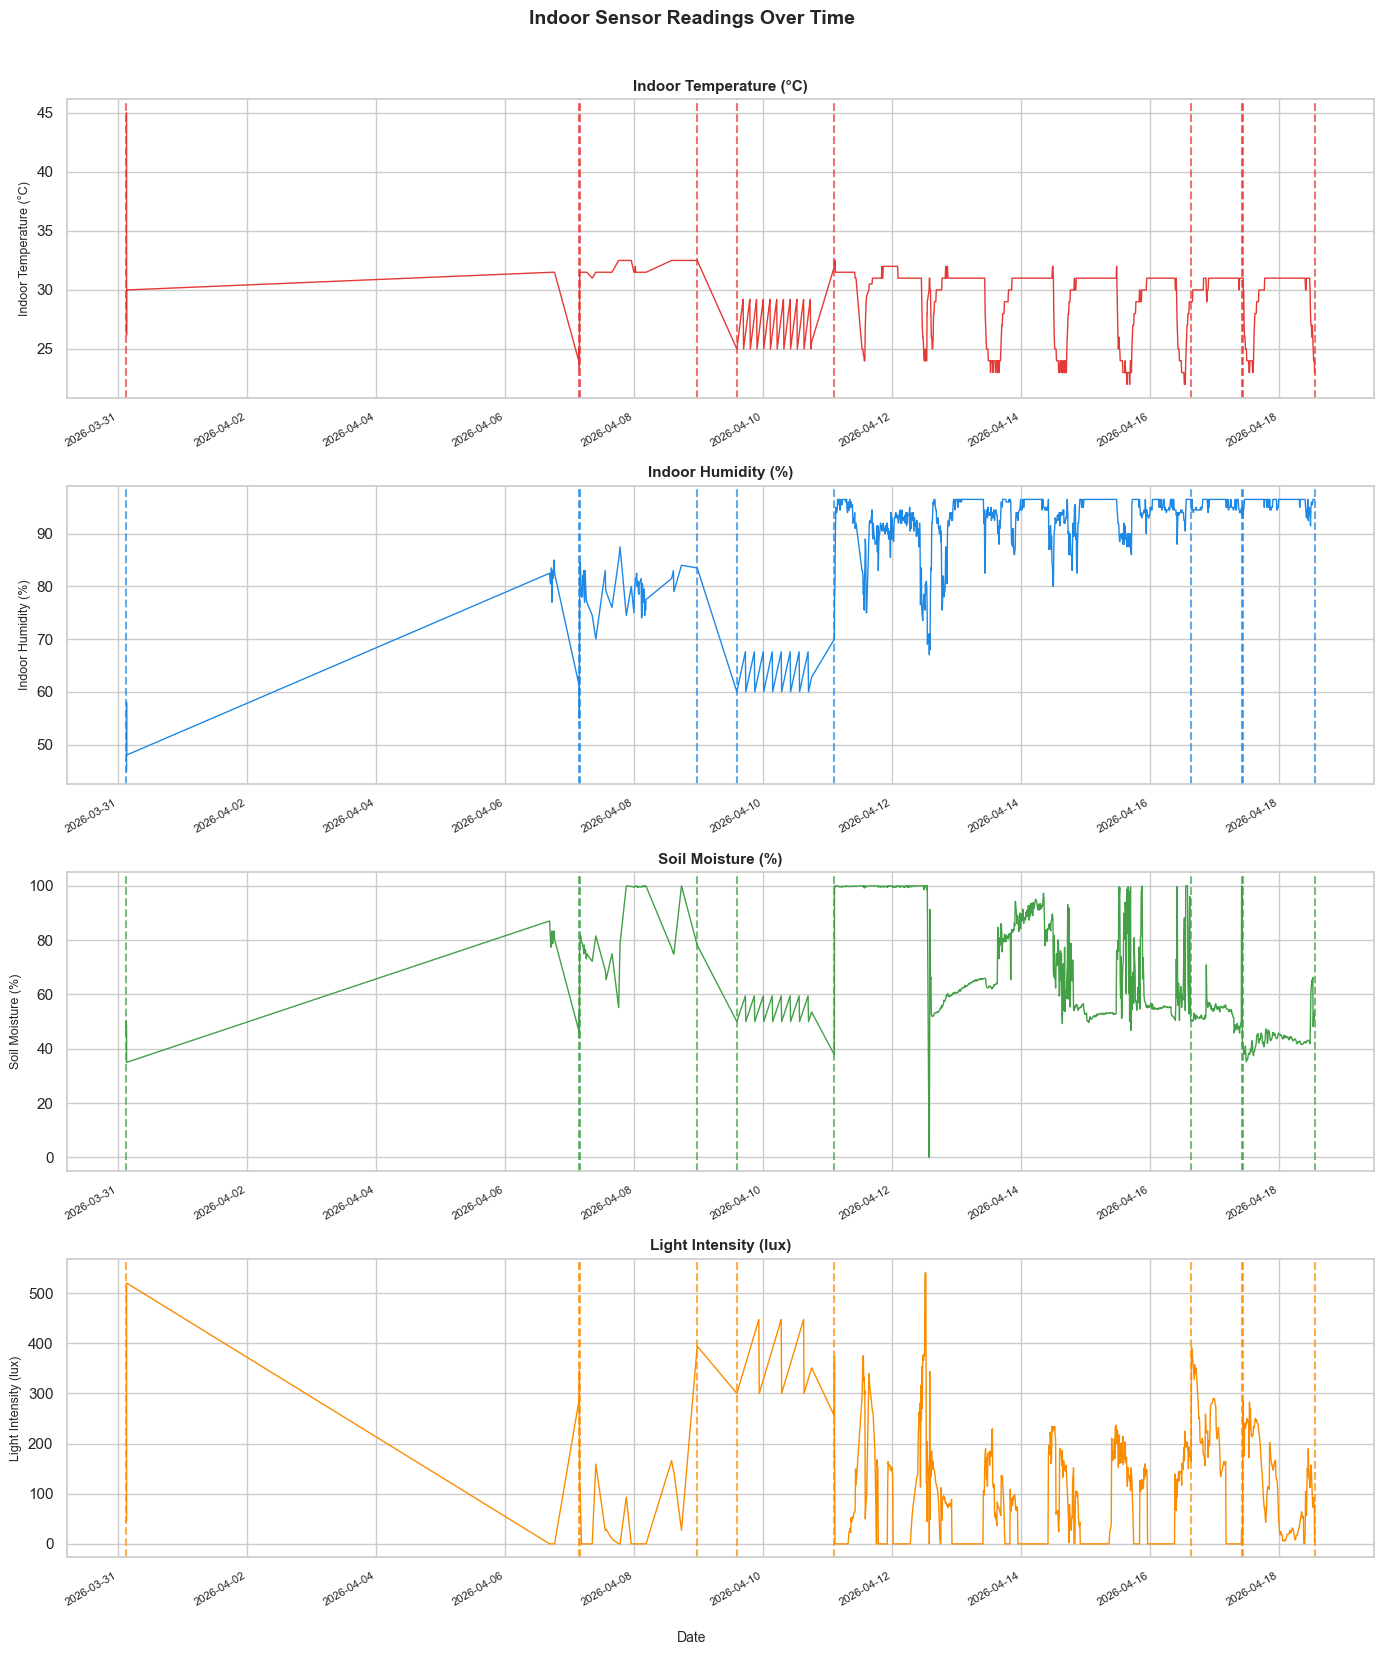

In [6]:
plot_cols = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux] if c is not None]

label_map = {
    col_temp_in:    "Indoor Temperature (°C)",
    col_hum_in:     "Indoor Humidity (%)",
    col_soil:       "Soil Moisture (%)",
    col_light_lux:  "Light Intensity (lux)",
}

color_map = {
    col_temp_in:   "#E53935",
    col_hum_in:    "#1E88E5",
    col_soil:      "#43A047",
    col_light_lux: "#FB8C00",
}

if plot_cols:
    # Creates one subplot per sensor, all sharing the same x-axis (time)
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 4 * len(plot_cols)), sharex=True)
    if len(plot_cols) == 1:
        axes = [axes]  # Ensure axes is always a list for consistent iteration below

    fig.suptitle("Indoor Sensor Readings Over Time", fontsize=14, fontweight="bold", y=1.01)

    stage_col_for_marker = col_stage_name if col_stage_name else col_stage
    if stage_col_for_marker:
        # Detect rows where the stage value changes — used to draw vertical stage-transition lines
        stage_changes = ag[stage_col_for_marker].astype(str).ne(ag[stage_col_for_marker].astype(str).shift(1))

    for ax, c in zip(axes, plot_cols):
        readable = label_map.get(c, c.replace("_", " ").title())
        color = color_map.get(c, "#546E7A")
        ax.plot(ag["ts"], ag[c], linewidth=1, color=color)
        ax.set_title(readable, fontsize=11, fontweight="bold", pad=6)
        ax.set_ylabel(readable, fontsize=9)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.tick_params(axis="x", labelbottom=True, labelrotation=30, labelsize=8)
        plt.setp(ax.xaxis.get_majorticklabels(), ha="right")
        if stage_changes is not None:
            # Draw a dashed vertical line at every point the plant transitions to a new stage
            for t in ag.loc[stage_changes, "ts"]:
                ax.axvline(t, linestyle="--", alpha=0.7, linewidth=1.5, color=color)

    fig.text(0.5, -0.01, "Date", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No sensor columns found for time-series plotting.")

## 2.4a Stage Distribution and Class Imbalance

**Goal:** Measure how much data exists for each stage and determine whether the classification problem is imbalanced before training begins.

**Method:** Count the number of rows in each growth stage and visualize the result with a biologically ordered bar chart.

**Processes:**
- **Harvested exclusion:** remove termination rows such as `harvested` because the models should learn stage progression, not the end-of-cycle event.
- **Biological ordering:** sort the categories as seedling → vegetative → bloom so the visual matches the real growth sequence instead of alphabetical order.
- **Count annotation:** print the exact number of rows above each bar so class imbalance is obvious at a glance.

**Why this matters:** Stage imbalance affects model training, metric stability, and the usefulness of accuracy-based intuition. If one class dominates the dataset, a model can look reasonable while still failing the minority stages.


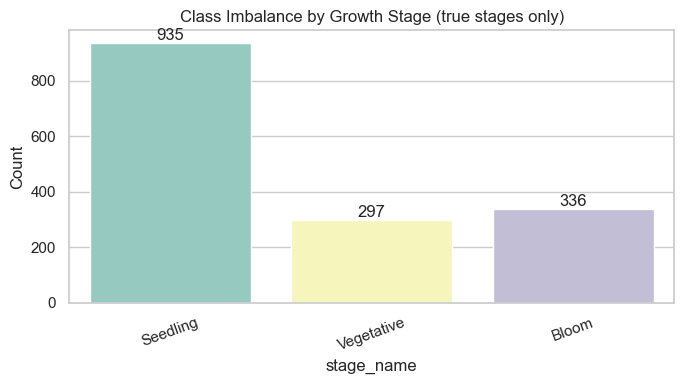

Stage counts (true stages only):
stage_name
Seedling      935
Vegetative    297
Bloom         336
Name: count, dtype: int64


In [7]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    print('No stage column found; skip stage-based plots.')
else:
    stage_values = ag[stage_col].astype(str).str.strip()
    # Exclude 'harvested' because it is a termination event, not a stage we want to model
    stage_values = stage_values[stage_values.str.lower() != 'harvested']
    counts = stage_values.value_counts()

    if counts.empty:
        print('No non-harvested stages found; skip stage-based plots.')
    else:
        # Force biological order (seedling → vegetative → bloom) instead of alphabetical
        stage_rank = {'seedling': 0, 'vegetative': 1, 'bloom': 2}
        ordered_labels = sorted(
            counts.index,
            key=lambda s: (stage_rank.get(str(s).strip().lower(), 99), str(s))
        )
        counts = counts.reindex(ordered_labels)

        plt.figure(figsize=(7, 4))
        sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="Set3", legend=False)
        plt.title('Class Imbalance by Growth Stage (true stages only)')
        plt.ylabel('Count')
        plt.xlabel(stage_col)
        plt.xticks(rotation=20)
        # Annotate exact count on top of each bar
        for i, v in enumerate(counts.values):
            plt.text(i, v, str(v), ha='center', va='bottom')
        plt.tight_layout()
        plt.show()

        print('Stage counts (true stages only):')
        print(counts)

## 2.4b Sensor Distribution by Growth Stage

**Goal:** Check whether each sensor has visibly different distributions across the growth stages and whether any feature appears to separate the classes on its own.

**Method:** Draw horizontal box plots for each sensor, grouped by stage, so the median, spread, and outliers can be compared side by side.

**Processes:**
- **Per-sensor plots:** iterate over every detected sensor column and create a dedicated distribution view.
- **Stage grouping:** place growth stage on the y-axis and sensor value on the x-axis, which makes stage-to-stage shifts easy to compare.
- **Outlier visibility:** the box-and-whisker format shows the tails and extreme values that can later affect model stability.

**Why this matters:** If the distributions overlap heavily, stage prediction will be inherently noisy. If some sensors show strong stage separation, those are likely to become the most useful engineered features later in the pipeline.


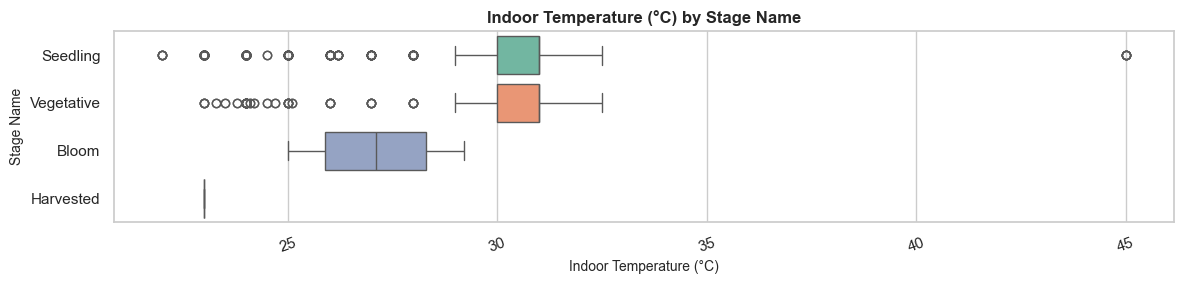

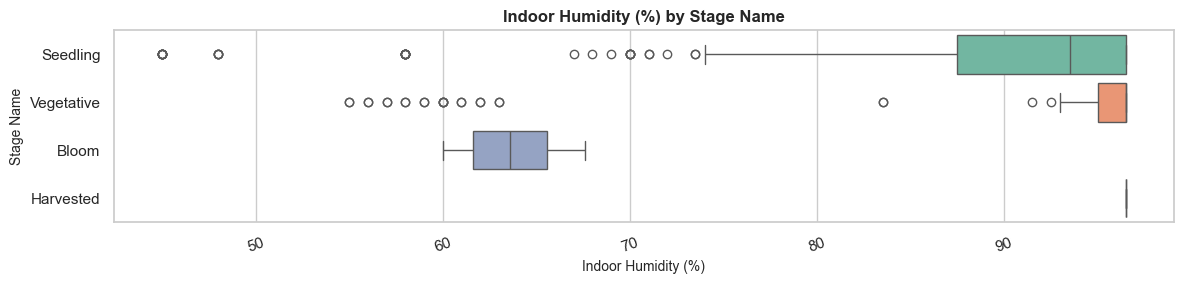

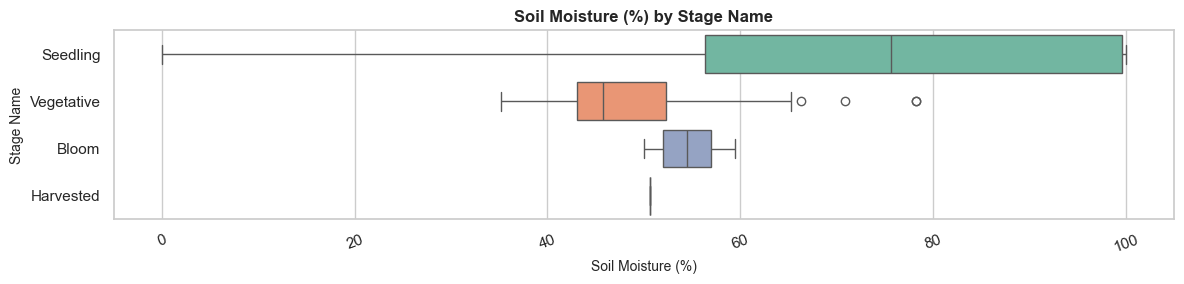

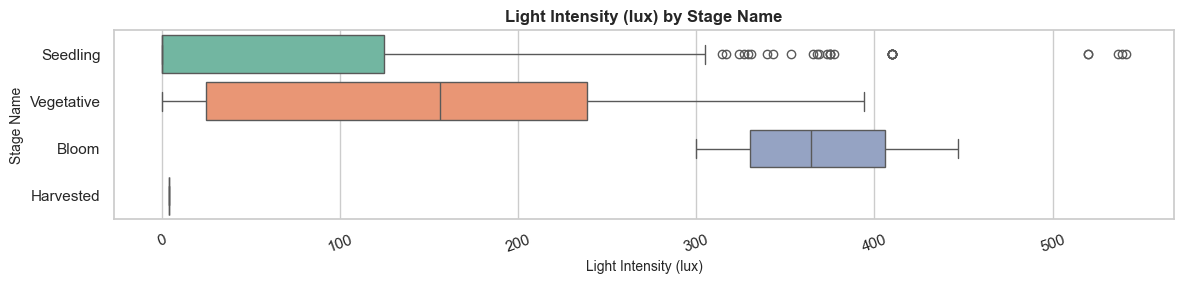

In [8]:
stage_col = col_stage_name if col_stage_name else col_stage

label_map = {
    col_temp_in:   "Indoor Temperature (°C)",
    col_hum_in:    "Indoor Humidity (%)",
    col_soil:      "Soil Moisture (%)",
    col_light_lux: "Light Intensity (lux)",
}

# Convert column name to readable title (e.g. "stage_name" → "Stage Name")
stage_label = stage_col.replace("_", " ").title() if stage_col else "Growth Stage"

if stage_col is not None:
    dist_cols = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux] if c is not None]
    # One box plot per sensor — shows how each sensor's distribution differs across stages
    for c in dist_cols:
        readable = label_map.get(c, c.replace("_", " ").title())
        plt.figure(figsize=(12, 3))
        sns.boxplot(data=ag, x=c, y=stage_col, hue=stage_col, palette="Set2", legend=False)
        plt.title(f"{readable} by {stage_label}", fontsize=12, fontweight="bold")
        plt.xlabel(readable, fontsize=10)
        plt.ylabel(stage_label, fontsize=10)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

## 2.5a Indoor vs Outdoor Data Merging

**Goal:** Merge the indoor growth data with outdoor weather data so the models can learn from both the plant sensors and the external environment.

**Method:** Aggregate both sources to hourly means and then inner join them on `hour_bucket`.

**Processes:**
- **Hourly aggregation:** average all readings within each hour so the two datasets are aligned at the same temporal resolution.
- **Conditional aggregation:** only aggregate columns that were actually detected, which keeps the merge robust to missing or renamed fields.
- **Inner join:** keep only the hours where both indoor and outdoor information exist so the combined table does not contain mismatched or partially missing rows.

**Why this matters:** Outdoor weather is not the target, but it provides context that may help explain indoor sensor behavior. This merge creates the foundation for weather-aware feature engineering and comparison plots.


In [9]:
# Build hourly averages for indoor sensors — only includes columns that were detected
indoor_agg = {}
if col_temp_in:
    indoor_agg['indoor_temp'] = (col_temp_in, 'mean')
if col_hum_in:
    indoor_agg['indoor_humidity'] = (col_hum_in, 'mean')
ag_hour = ag.groupby('hour_bucket').agg(**indoor_agg).reset_index() if indoor_agg else ag[['hour_bucket']].drop_duplicates()

# Same for outdoor — renames columns to fixed names (outdoor_temp, outdoor_humidity)
# so downstream code doesn't need to worry about the original DB column names
outdoor_agg = {}
if col_temp_out:
    outdoor_agg[col_temp_out_feat] = (col_temp_out, 'mean')
if col_hum_out:
    outdoor_agg[col_hum_out_feat] = (col_hum_out, 'mean')
wh_hour = wh.groupby('hour_bucket').agg(**outdoor_agg).reset_index() if outdoor_agg else wh[['hour_bucket']].drop_duplicates()

# Inner join on hour_bucket — only keeps hours where both indoor and outdoor data exist
merged_io = ag_hour.merge(wh_hour, on='hour_bucket', how='inner')
print('Indoor/outdoor merged rows:', len(merged_io))
display(merged_io.head())

Indoor/outdoor merged rows: 134


,hour_bucket,indoor_temp,indoor_humidity,outdoor_temp,outdoor_humidity
0,2026-04-13 00:00:00,31.0,96.250000,28.3,89.0
1,2026-04-13 01:00:00,31.0,96.333333,30.0,76.0
2,2026-04-13 02:00:00,31.0,96.500000,31.8,62.0
3,2026-04-13 03:00:00,31.0,96.500000,33.3,57.0
4,2026-04-13 04:00:00,31.0,96.500000,34.9,52.0


## 2.5b Indoor vs Outdoor Comparison Plot

**Goal:** Visually compare indoor and outdoor temperature and humidity to see how strongly the greenhouse or enclosure may be tracking the outside environment.

**Method:** Overlay indoor and outdoor line plots on the same time axis for both temperature and humidity.

**Processes:**
- **Two separate charts:** one for temperature and one for humidity so each variable can be inspected without visual clutter.
- **Shared timeline:** use the merged hourly data so the indoor and outdoor signals are directly comparable at the same points in time.
- **Guard conditions:** skip plotting when a required field is absent or the merge produced no rows, which prevents misleading empty figures.

**Why this matters:** If indoor and outdoor values move together, the external weather may be a meaningful contextual feature. If they are weakly related, the indoor control system may be buffering the plant environment strongly, which changes what the models can realistically learn.


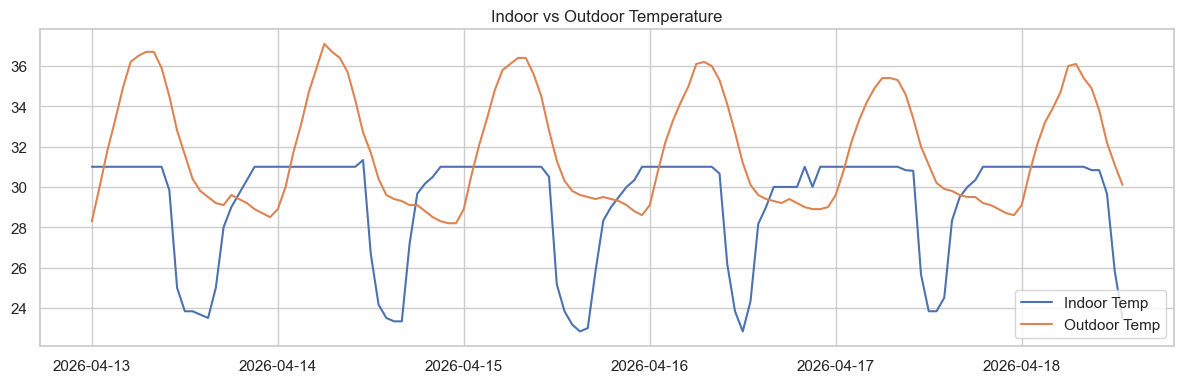

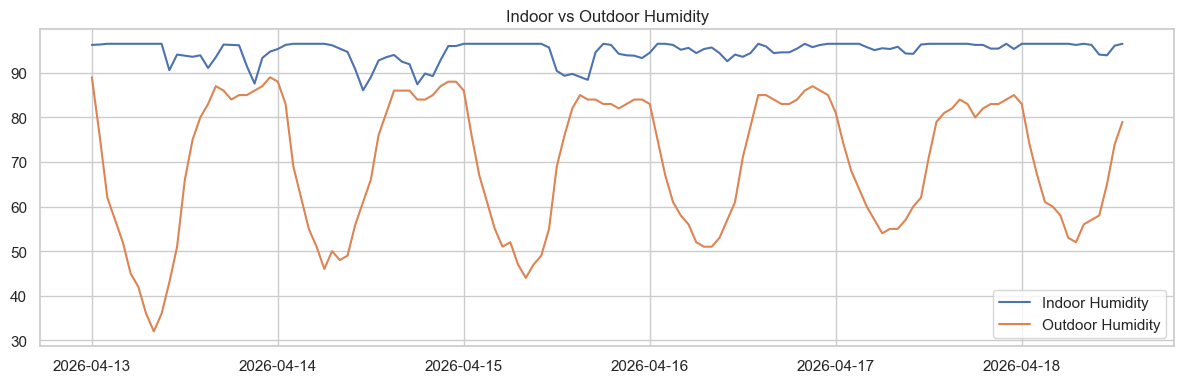

In [10]:
# Guard checks ensure we don't plot if columns are missing or the merge produced no rows
if 'indoor_temp' in merged_io.columns and col_temp_out_feat in merged_io.columns and not merged_io.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(merged_io['hour_bucket'], merged_io['indoor_temp'], label='Indoor Temp')
    plt.plot(merged_io['hour_bucket'], merged_io[col_temp_out_feat], label='Outdoor Temp')
    plt.title('Indoor vs Outdoor Temperature')
    plt.legend()
    plt.tight_layout()
    plt.show()

if 'indoor_humidity' in merged_io.columns and col_hum_out_feat in merged_io.columns and not merged_io.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(merged_io['hour_bucket'], merged_io['indoor_humidity'], label='Indoor Humidity')
    plt.plot(merged_io['hour_bucket'], merged_io[col_hum_out_feat], label='Outdoor Humidity')
    plt.title('Indoor vs Outdoor Humidity')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 2.6 Correlation Heatmap

**Goal:** Find linear relationships among the numeric columns so we can identify redundant features, strong paired signals, and variables that may contribute little to the model.

**Method:** Compute a Pearson correlation matrix and visualize it as a heatmap.

**Processes:**
- **Auto column selection:** include only numeric columns so text fields, timestamps, and categorical values do not trigger plotting errors.
- **Color anchoring:** center the palette at zero so positive and negative correlations are visually balanced and easy to interpret.
- **Feature screening:** use the heatmap to spot near-duplicate variables or unexpectedly strong relationships that might create redundancy later.

**Why this matters:** Correlation does not prove causation, but it is useful for pruning obvious overlap and understanding which inputs move together before the modeling stage introduces more complex relationships.


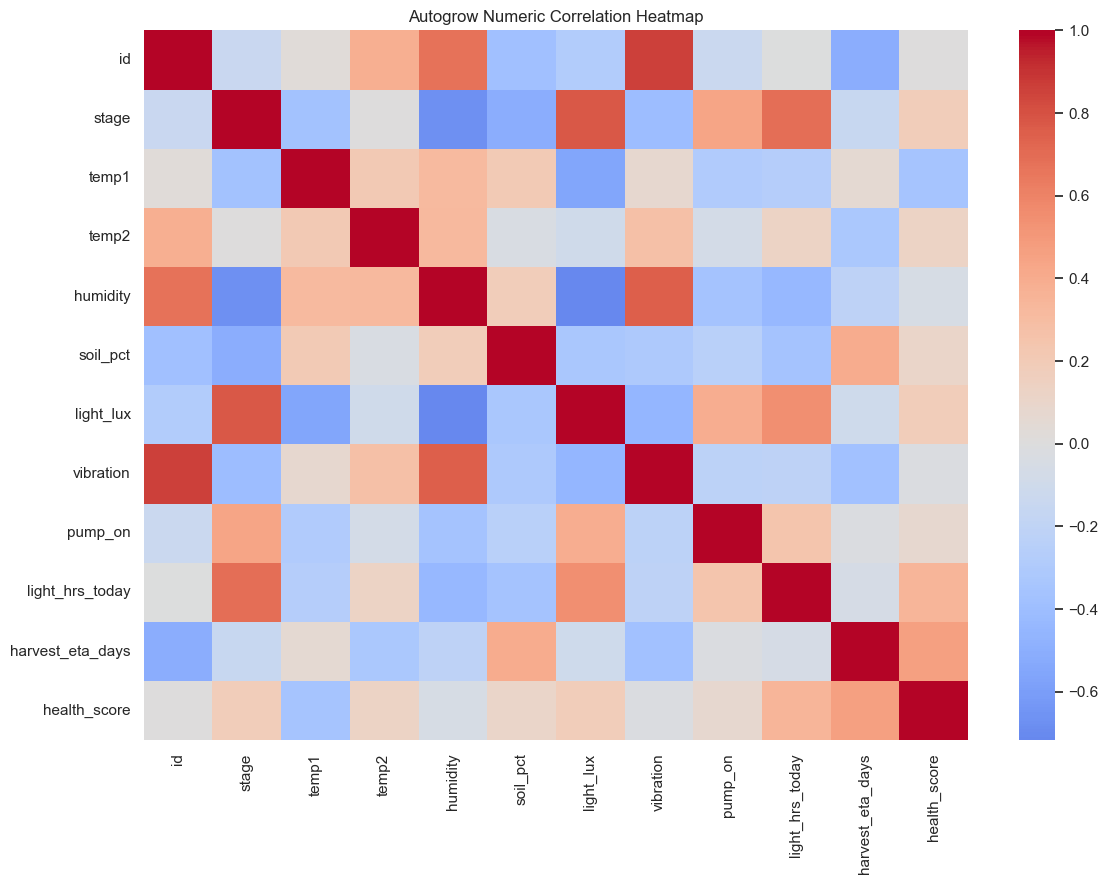

In [11]:
# Automatically selects only numeric columns — skips text/datetime columns that can't be correlated
numeric_cols = ag.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 9))
    # center=0 ensures the colormap is anchored at zero — red = positive, blue = negative correlation
    sns.heatmap(ag[numeric_cols].corr(), cmap='coolwarm', center=0)
    plt.title('Autogrow Numeric Correlation Heatmap')
    plt.tight_layout()
    plt.show()

## 3) Complex Data Pre-Processing Pipeline
This section turns the raw fused table into a model-ready dataset by removing obvious noise, checking missingness, and engineering time-aware features. The steps are intentionally separated so you can inspect the effect of each transformation on row count and feature quality.


## 3.1 Timestamp Alignment Check
**Goal:** Confirm that the indoor, outdoor, and fused tables are aligned on a compatible time axis before any cleaning step changes the row set.

**Method:** Compare timestamp coverage and alignment quality to make sure the later lag, rolling, and merge operations are built on valid time order.

**Why this matters:** Time alignment is the backbone of the whole notebook. If the timestamps are inconsistent here, the models can inherit silent leakage or learn from misaligned sensor values that do not actually belong to the same time window.


In [12]:
# Confirms row counts, hourly coverage, and time ranges before merging
print('Autogrow rows:', len(ag), '| Hour buckets:', ag['hour_bucket'].nunique())
print('Weather history rows:', len(wh), '| Hour buckets:', wh['hour_bucket'].nunique())
print('Autogrow start/end:', ag['ts'].min(), '->', ag['ts'].max())
print('Weather start/end:', wh['ts'].min(), '->', wh['ts'].max())

Autogrow rows: 1569 | Hour buckets: 231
Weather history rows: 144 | Hour buckets: 144
Autogrow start/end: 2026-03-31 03:02:57 -> 2026-04-18 13:18:29
Weather start/end: 2026-04-13 00:00:00 -> 2026-04-18 23:00:00


### 3.2 Outlier Detection (IQR)
**Goal:** Detect obvious sensor values that are far outside the typical operating range and could distort downstream statistics or model fitting.

**Method:** Compute interquartile-range thresholds for the selected numeric columns and treat values outside the Tukey fences as suspicious.

**Processes:**
- Compute the first and third quartiles for each monitored column.
- Derive the lower and upper fences with `Q1 - 1.5 * IQR` and `Q3 + 1.5 * IQR`.
- Flag readings that sit far away from the central mass of the data.

**Why this matters:** In sensor data, extreme values can come from real events, but they can also come from glitches, dropouts, or temporary calibration issues. IQR screening gives a simple first pass for identifying those extremes.


In [13]:
prep = ag.copy()
outlier_cols = [c for c in [col_soil, col_temp_in] if c is not None]
outlier_stats = []

for c in outlier_cols:
    s = pd.to_numeric(prep[c], errors='coerce')
    # IQR method: anything below Q1 - 1.5×IQR or above Q3 + 1.5×IQR is flagged as an outlier
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    outlier_stats.append({
        'column': c,
        'q1': q1,
        'q3': q3,
        'low': low,
        'high': high,
        'outlier_count': int(mask.sum())
    })

# Display stats only — rows are not removed yet, that happens in the next step
outlier_stats_df = pd.DataFrame(outlier_stats)
display(outlier_stats_df)

,column,q1,q3,low,high,outlier_count
0,soil_pct,52.5,81.8,8.55,125.75,4
1,temp1,27.1,31.0,21.25,36.85,6


### 3.3 Outlier Handling Result
**Goal:** Remove the strongest outliers and measure how much data was kept versus discarded.

**Method:** Apply the IQR-based mask to the monitored columns and compare row counts before and after filtering.

**Processes:**
- Compute IQR bounds for each monitored column.
- Keep only the rows that stay inside the accepted thresholds.
- Report the row-count impact so you can see whether the filter was conservative or aggressive.

**Why this matters:** The aim is not to delete rare but meaningful plant behavior. The goal is to remove values that are clearly incompatible with the rest of the run while preserving as much valid signal as possible.


In [14]:
keep = pd.Series(True, index=prep.index)
for c in outlier_cols:
    s = pd.to_numeric(prep[c], errors='coerce')
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    keep &= s.between(low, high) | s.isna()

prep_iqr = prep[keep].copy()
print('Rows before IQR filter:', len(prep))
print('Rows after IQR filter :', len(prep_iqr))
print('Rows removed          :', len(prep) - len(prep_iqr))


Rows before IQR filter: 1569
Rows after IQR filter : 1559
Rows removed          : 10


### 3.3b Advanced Outlier Detection: Isolation Forest (Stage 1 — Beyond Course)
**Goal:** Add an unsupervised anomaly detector that can catch multi-column outliers that the column-wise IQR filter may miss.

**Method:** Fit `IsolationForest` on the imputed numeric sensor matrix and use it to identify rows that look unusual across the combined feature space.

**Processes:**
- Fit `IsolationForest(contamination=0.02, random_state=42)` on the sensor features.
- Flag rows that are anomalous in the joint space of multiple sensors, not just one column at a time.
- Keep the inlier rows for `prep_clean` so the later models train on a cleaner dataset.

**Why this matters:** IQR catches obvious single-column spikes, but it does not know whether a combination of individually plausible values still looks suspicious overall. Isolation Forest complements the rule-based filter with a broader anomaly view.


Isolation Forest | Features: ['soil_pct', 'temp1', 'humidity', 'light_lux']
  Total rows      : 1559
  IF Outliers     : 32 (2.05%)
  Clean inliers   : 1527


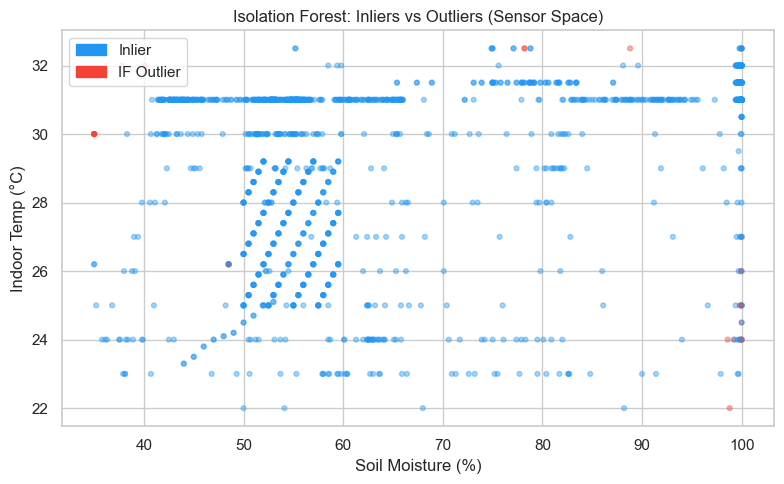


Rows after IQR + IF pipeline: 1527 (removed 32 additional rows by IF)


In [15]:
iso_cols = [c for c in [col_soil, col_temp_in, col_hum_in, col_light_lux]
            if c is not None and c in prep_iqr.columns]

if len(iso_cols) >= 2:
    iso_input = prep_iqr[iso_cols].copy()
    iso_imputer = SimpleImputer(strategy='median')
    iso_input_imp = iso_imputer.fit_transform(iso_input)

    iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
    iso_labels = iso_forest.fit_predict(iso_input_imp)  # 1=inlier, -1=outlier
    prep_iqr['isolation_flag'] = iso_labels

    n_outliers = (iso_labels == -1).sum()
    n_total = len(iso_labels)
    print(f'Isolation Forest | Features: {iso_cols}')
    print(f'  Total rows      : {n_total}')
    print(f'  IF Outliers     : {n_outliers} ({100*n_outliers/n_total:.2f}%)')
    print(f'  Clean inliers   : {n_total - n_outliers}')

    # Visualise: IQR-only vs IQR+IF
    colors = ['#2196F3' if v == 1 else '#F44336' for v in iso_labels]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(iso_input_imp[:, 0], iso_input_imp[:, 1],
               c=colors, alpha=0.4, s=12)
    ax.legend(handles=[
        mpatches.Patch(color='#2196F3', label='Inlier'),
        mpatches.Patch(color='#F44336', label='IF Outlier')
    ])
    label_map = {
        col_soil:      'Soil Moisture (%)',
        col_temp_in:   'Indoor Temp (°C)',
        col_hum_in:    'Indoor Humidity (%)',
        col_light_lux: 'Light Intensity (lux)',
    }
    ax.set_xlabel(label_map.get(iso_cols[0], iso_cols[0].replace('_', ' ').title()))
    ax.set_ylabel(label_map.get(iso_cols[1], iso_cols[1].replace('_', ' ').title()))
    ax.set_title('Isolation Forest: Inliers vs Outliers (Sensor Space)')
    plt.tight_layout()
    plt.show()

    prep_clean = prep_iqr[prep_iqr['isolation_flag'] == 1].drop(columns=['isolation_flag']).copy()
    print(f'\nRows after IQR + IF pipeline: {len(prep_clean)} '
          f'(removed {len(prep_iqr) - len(prep_clean)} additional rows by IF)')
else:
    print('Not enough sensor columns for Isolation Forest; using IQR-only filtered data.')
    prep_clean = prep_iqr.copy()


### 3.4 Missing-Value Audit
**Goal:** Make missingness explicit before imputation so the notebook knows which columns are weak, incomplete, or likely to require heavier preprocessing.

**Method:** Count null values column by column after the outlier filters have been applied.

**Processes:**
- Count missing values for each feature.
- Print the summary so problematic columns are visible early.
- Use the audit to decide how much the model should rely on imputation versus naturally complete features.

**Why this matters:** Missing values are not just a technical nuisance. They can be a sign that the underlying sensor stream is sparse, intermittent, or partially unreliable, which affects the confidence you should place in the resulting model.


In [16]:
# Null audit after full cleaning pipeline (IQR + Isolation Forest)
nulls_after_clean = prep_clean.isna().sum().sort_values(ascending=False)
display(nulls_after_clean[nulls_after_clean > 0].to_frame('null_count'))
print(f'Rows in prep_clean: {len(prep_clean)}')


,null_count
spectrum,13


Rows in prep_clean: 1527


### 3.5 Multi-Source Fusion
**Goal:** Combine the cleaned indoor table with outdoor context and daylight information into a single modeling frame.

**Method:** Join `prep_iqr` with hourly outdoor weather history and daylight-hour signals so each indoor observation carries the environmental context for the same time window.

**Processes:**
- Align indoor rows to the nearest hourly weather bucket.
- Merge weather history, daylight duration, and the cleaned indoor measurements into one frame.
- Preserve the fused table as the base dataset for feature engineering and model preparation.

**Why this matters:** This is the point where the notebook stops treating indoor sensors as isolated readings. The merged table lets later models use outside conditions, which may explain part of the variation in indoor temperature, humidity, and plant-state transitions.


In [17]:
feat = prep_clean.copy()

outdoor_agg = {}
if col_temp_out:
    outdoor_agg[col_temp_out_feat] = (col_temp_out, 'mean')
if col_hum_out:
    outdoor_agg[col_hum_out_feat] = (col_hum_out, 'mean')

if outdoor_agg:
    wh_hourly_feat = wh.groupby('hour_bucket').agg(**outdoor_agg).reset_index()
    feat = feat.merge(wh_hourly_feat, on='hour_bucket', how='left')
else:
    feat[col_temp_out_feat] = np.nan
    feat[col_hum_out_feat] = np.nan

col_sunrise = first_existing(wc.columns, ['sunrise_utc', 'sunrise'])
col_sunset = first_existing(wc.columns, ['sunset_utc', 'sunset'])
if col_sunrise and col_sunset:
    wc_tmp = wc.copy()
    wc_tmp['sunrise_dt'] = pd.to_datetime(wc_tmp[col_sunrise], errors='coerce', utc=True).dt.tz_localize(None)
    wc_tmp['sunset_dt'] = pd.to_datetime(wc_tmp[col_sunset], errors='coerce', utc=True).dt.tz_localize(None)
    wc_tmp['daylight_hours'] = (wc_tmp['sunset_dt'] - wc_tmp['sunrise_dt']).dt.total_seconds() / 3600
    if 'ts' in wc_tmp.columns and wc_tmp['ts'].notna().any():
        wc_tmp['date'] = wc_tmp['ts'].dt.date
    else:
        wc_tmp['date'] = wc_tmp['sunrise_dt'].dt.date
    daylight_df = wc_tmp.groupby('date', as_index=False)['daylight_hours'].mean()
    feat['date'] = feat['ts'].dt.date
    feat = feat.merge(daylight_df, on='date', how='left')
else:
    feat['daylight_hours'] = np.nan

print('Feature table shape after merge:', feat.shape)
display(feat.head())


Feature table shape after merge: (1527, 21)


,id,ts,stage,stage_name,spectrum,temp1,temp2,humidity,soil_pct,light_lux,vibration,pump_on,pump_status,light_hrs_today,harvest_eta_days,health_score,hour_bucket,outdoor_temp,outdoor_humidity,date,daylight_hours
0,10,2026-03-31 03:13:40,0,Seedling,OFF,26.2,0.0,58.0,48.5,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
1,176,2026-03-31 03:13:40,0,Seedling,NaN,26.2,26.2,58.0,48.5,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
2,11,2026-03-31 03:13:46,0,Seedling,OFF,26.2,0.0,58.0,35.0,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
3,177,2026-03-31 03:13:46,0,Seedling,NaN,26.2,26.2,58.0,35.0,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
4,181,2026-04-06 16:39:46,0,Seedling,NaN,31.5,31.5,82.5,87.1,0.0,0,0,OK,0.0,0,0,2026-04-06 16:00:00,NaN,NaN,2026-04-06,NaN


### 3.6 Feature Engineering
**Goal:** Turn the fused table into a richer but still leakage-safe modeling dataset that captures short-term history, periodic patterns, and interactions between sensors.

**Method:** Build lag features, rolling summaries, time-of-day encodings, and selected sensor interactions while avoiding direct use of target-like variables in the classifier input.

**Processes:**
- Derive short- and medium-history features from the chronological sensor stream.
- Add cyclical time features so the model can represent daily timing without hard cutoffs.
- Create interaction terms that capture combined sensor effects rather than only single-feature trends.
- Keep stage-derived diagnostics available for analysis, but not as direct classifier inputs.

**Why this matters:** The raw sensor values alone are often too noisy to separate growth stages. Engineered temporal context gives the model a chance to learn the trend behind the measurements instead of reacting to a single point in time.


In [18]:
feat = feat.sort_values('ts').copy()

stage_col = col_stage_name if col_stage_name else col_stage
if stage_col:
    feat['stage_label'] = feat[stage_col].astype(str)
else:
    feat['stage_label'] = 'unknown'

stage_key = feat['stage_label'].str.lower().str.strip()

# Time-progress features help the classifier understand growth-stage progression.
feat['dayofweek'] = feat['ts'].dt.dayofweek
feat['dow_sin'] = np.sin(2 * np.pi * feat['dayofweek'] / 7)
feat['dow_cos'] = np.cos(2 * np.pi * feat['dayofweek'] / 7)
feat['is_weekend'] = (feat['dayofweek'] >= 5).astype(int)

# Short-history features from the existing timeline. We do not use future rows,
# only prior observations, so these features stay valid for chronological models.
lag_sources = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs] if c is not None and c in feat.columns]
for col in lag_sources:
    s = pd.to_numeric(feat[col], errors='coerce')
    feat[f'{col}_lag1'] = s.shift(1)
    feat[f'{col}_lag2'] = s.shift(2)
    feat[f'{col}_lag3'] = s.shift(3)
    feat[f'{col}_lag6'] = s.shift(6)
    feat[f'{col}_lag12'] = s.shift(12)
    feat[f'{col}_delta1'] = s - feat[f'{col}_lag1']
    feat[f'{col}_delta3'] = s - feat[f'{col}_lag3']
    feat[f'{col}_delta6'] = s - feat[f'{col}_lag6']
    feat[f'{col}_rollmean3'] = s.shift(1).rolling(window=3, min_periods=1).mean()
    feat[f'{col}_rollstd3'] = s.shift(1).rolling(window=3, min_periods=2).std()
    feat[f'{col}_rollmean6'] = s.shift(1).rolling(window=6, min_periods=2).mean()
    feat[f'{col}_rollstd6'] = s.shift(1).rolling(window=6, min_periods=3).std()
    feat[f'{col}_rollmean12'] = s.shift(1).rolling(window=12, min_periods=3).mean()
    feat[f'{col}_rollstd12'] = s.shift(1).rolling(window=12, min_periods=4).std()

feat['minutes_since_prev'] = feat['ts'].diff().dt.total_seconds().div(60.0)

if col_soil:
    soil_target_map = {'seedling': 70, 'vegetative': 60, 'bloom': 50}
    feat['soil_target'] = stage_key.map(soil_target_map).fillna(60)
    feat['soil_deviation'] = pd.to_numeric(feat[col_soil], errors='coerce') - feat['soil_target']

if col_temp_in and col_temp_out_feat in feat.columns:
    feat['temp_delta'] = pd.to_numeric(feat[col_temp_in], errors='coerce') - pd.to_numeric(feat[col_temp_out_feat], errors='coerce')

if col_light_hrs:
    light_target_map = {'seedling': 6, 'vegetative': 12, 'bloom': 12}
    feat['light_target'] = stage_key.map(light_target_map).fillna(12)
    feat['light_deficit'] = feat['light_target'] - pd.to_numeric(feat[col_light_hrs], errors='coerce')

feat['hour'] = feat['ts'].dt.hour
feat['hour_sin'] = np.sin(2 * np.pi * feat['hour'] / 24)
feat['hour_cos'] = np.cos(2 * np.pi * feat['hour'] / 24)

# Light interaction features help capture nonlinear sensor combinations without using labels.
if col_temp_in and col_hum_in:
    temp_in_num = pd.to_numeric(feat[col_temp_in], errors='coerce')
    hum_in_num = pd.to_numeric(feat[col_hum_in], errors='coerce')
    feat['temp_humidity_interaction'] = temp_in_num * hum_in_num
    feat['temp_humidity_gap'] = temp_in_num - hum_in_num

if col_temp_in and col_soil:
    temp_in_num = pd.to_numeric(feat[col_temp_in], errors='coerce')
    soil_num = pd.to_numeric(feat[col_soil], errors='coerce')
    feat['temp_soil_interaction'] = temp_in_num * soil_num

if col_temp_in and col_light_lux:
    temp_in_num = pd.to_numeric(feat[col_temp_in], errors='coerce')
    light_num = pd.to_numeric(feat[col_light_lux], errors='coerce')
    feat['temp_light_interaction'] = temp_in_num * light_num

if col_hum_in and col_soil:
    hum_in_num = pd.to_numeric(feat[col_hum_in], errors='coerce')
    soil_num = pd.to_numeric(feat[col_soil], errors='coerce')
    feat['humidity_soil_interaction'] = hum_in_num * soil_num

# Trend features compare the current value to recent history.
for col in lag_sources:
    s = pd.to_numeric(feat[col], errors='coerce')
    feat[f'{col}_trend6'] = s - s.shift(6).rolling(window=6, min_periods=3).mean()
    feat[f'{col}_trend12'] = s - s.shift(12).rolling(window=12, min_periods=4).mean()

# Add a light smoothing layer for outdoor context as well.
for c in [col_temp_out_feat, col_hum_out_feat]:
    if c in feat.columns:
        s = pd.to_numeric(feat[c], errors='coerce')
        feat[f'{c}_lag1'] = s.shift(1)
        feat[f'{c}_lag3'] = s.shift(3)
        feat[f'{c}_rollmean6'] = s.shift(1).rolling(window=6, min_periods=2).mean()
        feat[f'{c}_rollstd6'] = s.shift(1).rolling(window=6, min_periods=3).std()

preview_cols = [c for c in [
    'ts', 'stage_label', col_temp_in, col_hum_in, col_soil, col_light_hrs,
    col_temp_out_feat, col_hum_out_feat,
    'soil_deviation', 'temp_delta', 'light_deficit',
    f'{col_temp_in}_lag1' if col_temp_in else None,
    f'{col_temp_in}_lag6' if col_temp_in else None,
    f'{col_hum_in}_lag1' if col_hum_in else None,
    f'{col_hum_in}_lag6' if col_hum_in else None,
    'minutes_since_prev', 'hour_sin', 'hour_cos', 'daylight_hours'
] if c is not None and c in feat.columns]
display(feat[preview_cols].head())


/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_20105/1318950193.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat[f'{col}_trend6'] = s - s.shift(6).rolling(window=6, min_periods=3).mean()
/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_20105/1318950193.py:82: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat[f'{col}_trend12'] = s - s.shift(12).rolling(window=12, min_periods=4).mean()
/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_20105/1318950193.py:88: PerformanceWarning: DataFrame is

,ts,stage_label,temp1,humidity,soil_pct,light_hrs_today,outdoor_temp,outdoor_humidity,soil_deviation,temp_delta,light_deficit,temp1_lag1,temp1_lag6,humidity_lag1,humidity_lag6,minutes_since_prev,hour_sin,hour_cos,daylight_hours
0,2026-03-31 03:13:40,Seedling,26.2,58.0,48.5,0.0,NaN,NaN,-21.5,NaN,6.0,NaN,NaN,NaN,NaN,NaN,0.707107,0.707107,NaN
1,2026-03-31 03:13:40,Seedling,26.2,58.0,48.5,0.0,NaN,NaN,-21.5,NaN,6.0,26.2,NaN,58.0,NaN,0.0,0.707107,0.707107,NaN
2,2026-03-31 03:13:46,Seedling,26.2,58.0,35.0,0.0,NaN,NaN,-35.0,NaN,6.0,26.2,NaN,58.0,NaN,0.1,0.707107,0.707107,NaN
3,2026-03-31 03:13:46,Seedling,26.2,58.0,35.0,0.0,NaN,NaN,-35.0,NaN,6.0,26.2,NaN,58.0,NaN,0.0,0.707107,0.707107,NaN
4,2026-04-06 16:39:46,Seedling,31.5,82.5,87.1,0.0,NaN,NaN,17.1,NaN,6.0,26.2,NaN,58.0,NaN,9446.0,-0.866025,-0.500000,NaN


### 3.7 Class Distribution & Balancing Setup

**Goal:** Inspect the stage imbalance and prepare the balancing strategy that will be used during model training.

**Method:** Use `value_counts()` to measure the class distribution, then make SMOTE and random oversampling available for controlled experiments.

**Processes:**
- Print the class counts for each stage so imbalance is visible before any model is fit.
- Check that SMOTE is available in the current environment.
- Keep the balancing choice explicit, so later comparisons are not accidentally mixing different sampling strategies.

**Why this matters:** The final results can be misleading if the class distribution is not understood up front. This step makes the training setup transparent and makes it easier to tell whether poor results are caused by imbalance, limited data, or weak features.


In [19]:
smote_available = False

# 1. Calculate how many examples we have for each growth stage
if col_stage_name and col_stage_name in feat.columns or col_stage and col_stage in feat.columns:
    stage_col_check = col_stage_name if col_stage_name else col_stage
    counts = feat[stage_col_check].astype(str).value_counts()
    print('Class distribution:')
    print(counts)

# 2. Load the SMOTE tool (already guaranteed by the ensure_package check at the top)
try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
    print('SMOTE available: True')
except ImportError:
    print('SMOTE available: False (fallback to class_weight)')


Class distribution:
stage_name
Seedling      895
Bloom         336
Vegetative    295
Harvested       1
Name: count, dtype: int64
SMOTE available: True


## 4.1 Model Data Preparation & Train/Test Split
**Goal:** Build a training set and holdout set that respect time order so future information does not leak into the past.

**Method:** Split by a fixed date when possible, otherwise fall back to a time-based 80% cutoff based on the observed timestamp range.

**Processes:**
- Sort the table chronologically.
- Use an explicit date split when the dataset span makes that valid.
- Fall back to a timestamp quantile split if the hard cutoff is not inside the data range.
- Train on the earlier period and evaluate on the later period so the holdout score reflects real forecasting conditions.

**Why this matters:** Random splits are usually too optimistic for time series. A chronological split is stricter and better matches how the model would behave on new plant data that arrives in the future.


In [20]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    raise ValueError('No stage label found for classification task.')

model_df = feat.dropna(subset=['ts']).sort_values('ts').copy()
model_df['target_stage'] = model_df[stage_col].astype(str).str.strip()
model_df['target_stage_key'] = model_df['target_stage'].str.lower()

# Predict only true growth stages; exclude termination events such as harvested.
allowed_stage_keys = ['seedling', 'vegetative', 'bloom']
model_df = model_df[model_df['target_stage_key'].isin(allowed_stage_keys)].copy()
model_df['target_stage'] = model_df['target_stage_key']
stage_order_map = {'seedling': 0, 'vegetative': 1, 'bloom': 2}
model_df['target_stage_order'] = model_df['target_stage'].map(stage_order_map)

# Drop rows near a stage transition because those samples are usually the noisiest.
stage_rows_before_transition = len(model_df)
stage_change = model_df['target_stage'].ne(model_df['target_stage'].shift(1))
transition_window = (
    stage_change
    | stage_change.shift(1, fill_value=False)
    | stage_change.shift(-1, fill_value=False)
)
strict_model_df = model_df.loc[~transition_window].copy()

if len(strict_model_df) >= max(50, int(0.5 * stage_rows_before_transition)):
    model_df = strict_model_df
    print(f'Applied transition filtering: kept {len(model_df)} of {stage_rows_before_transition} stage rows.')
else:
    print(
        f'Transition filtering removed too many rows ({len(strict_model_df)} of '
        f'{stage_rows_before_transition}); keeping stage-only rows without boundary pruning.'
    )

model_df = model_df.drop(columns=['target_stage_key'])

vc = model_df['target_stage'].value_counts()
valid_classes = vc[vc >= 5].index
model_df = model_df[model_df['target_stage'].isin(valid_classes)].copy()
model_df['target_stage_order'] = model_df['target_stage'].map(stage_order_map)
print('Stage counts after target cleanup:')
display(model_df['target_stage'].value_counts())

leaky_cols = [
    'harvest_eta_days', # Direct countdown to harvest (perfect stage proxy)
    'health_score',     # Often calculated using the plant's age/stage
    'id',               # Row IDs can allow the model to memorize sequences
    'ts'                # Raw timestamps are handled by the split, don't use as feature
]

model_df = model_df.drop(columns=[c for c in leaky_cols if c in model_df.columns])
print(f"Removed potential leaky columns to ensure honest results.")

feature_candidates = [
    col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs,
    col_temp_out_feat, col_hum_out_feat,
    f'{col_temp_out_feat}_lag1' if col_temp_out_feat else None,
    f'{col_temp_out_feat}_lag3' if col_temp_out_feat else None,
    f'{col_temp_out_feat}_rollmean6' if col_temp_out_feat else None,
    f'{col_temp_out_feat}_rollstd6' if col_temp_out_feat else None,
    f'{col_hum_out_feat}_lag1' if col_hum_out_feat else None,
    f'{col_hum_out_feat}_lag3' if col_hum_out_feat else None,
    f'{col_hum_out_feat}_rollmean6' if col_hum_out_feat else None,
    f'{col_hum_out_feat}_rollstd6' if col_hum_out_feat else None,
    'temp_delta', 'minutes_since_prev',
    'temp_humidity_interaction', 'temp_humidity_gap', 'temp_soil_interaction', 'temp_light_interaction', 'humidity_soil_interaction',
    'dow_sin', 'dow_cos', 'is_weekend', 'hour_sin', 'hour_cos', 'daylight_hours',
    f'{col_temp_in}_lag1' if col_temp_in else None,
    f'{col_temp_in}_lag2' if col_temp_in else None,
    f'{col_temp_in}_lag3' if col_temp_in else None,
    f'{col_temp_in}_lag6' if col_temp_in else None,
    f'{col_temp_in}_lag12' if col_temp_in else None,
    f'{col_temp_in}_delta1' if col_temp_in else None,
    f'{col_temp_in}_delta3' if col_temp_in else None,
    f'{col_temp_in}_delta6' if col_temp_in else None,
    f'{col_temp_in}_rollmean3' if col_temp_in else None,
    f'{col_temp_in}_rollstd3' if col_temp_in else None,
    f'{col_temp_in}_rollmean6' if col_temp_in else None,
    f'{col_temp_in}_rollstd6' if col_temp_in else None,
    f'{col_temp_in}_rollmean12' if col_temp_in else None,
    f'{col_temp_in}_rollstd12' if col_temp_in else None,
    f'{col_temp_in}_trend6' if col_temp_in else None,
    f'{col_temp_in}_trend12' if col_temp_in else None,
    f'{col_hum_in}_lag1' if col_hum_in else None,
    f'{col_hum_in}_lag2' if col_hum_in else None,
    f'{col_hum_in}_lag3' if col_hum_in else None,
    f'{col_hum_in}_lag6' if col_hum_in else None,
    f'{col_hum_in}_lag12' if col_hum_in else None,
    f'{col_hum_in}_delta1' if col_hum_in else None,
    f'{col_hum_in}_delta3' if col_hum_in else None,
    f'{col_hum_in}_delta6' if col_hum_in else None,
    f'{col_hum_in}_rollmean3' if col_hum_in else None,
    f'{col_hum_in}_rollstd3' if col_hum_in else None,
    f'{col_hum_in}_rollmean6' if col_hum_in else None,
    f'{col_hum_in}_rollstd6' if col_hum_in else None,
    f'{col_hum_in}_rollmean12' if col_hum_in else None,
    f'{col_hum_in}_rollstd12' if col_hum_in else None,
    f'{col_hum_in}_trend6' if col_hum_in else None,
    f'{col_hum_in}_trend12' if col_hum_in else None,
    f'{col_soil}_lag1' if col_soil else None,
    f'{col_soil}_lag2' if col_soil else None,
    f'{col_soil}_lag3' if col_soil else None,
    f'{col_soil}_lag6' if col_soil else None,
    f'{col_soil}_lag12' if col_soil else None,
    f'{col_soil}_delta1' if col_soil else None,
    f'{col_soil}_delta3' if col_soil else None,
    f'{col_soil}_delta6' if col_soil else None,
    f'{col_soil}_rollmean3' if col_soil else None,
    f'{col_soil}_rollstd3' if col_soil else None,
    f'{col_soil}_rollmean6' if col_soil else None,
    f'{col_soil}_rollstd6' if col_soil else None,
    f'{col_soil}_rollmean12' if col_soil else None,
    f'{col_soil}_rollstd12' if col_soil else None,
    f'{col_soil}_trend6' if col_soil else None,
    f'{col_soil}_trend12' if col_soil else None,
    f'{col_light_lux}_lag1' if col_light_lux else None,
    f'{col_light_lux}_lag2' if col_light_lux else None,
    f'{col_light_lux}_lag3' if col_light_lux else None,
    f'{col_light_lux}_lag6' if col_light_lux else None,
    f'{col_light_lux}_lag12' if col_light_lux else None,
    f'{col_light_lux}_delta1' if col_light_lux else None,
    f'{col_light_lux}_delta3' if col_light_lux else None,
    f'{col_light_lux}_delta6' if col_light_lux else None,
    f'{col_light_lux}_rollmean3' if col_light_lux else None,
    f'{col_light_lux}_rollstd3' if col_light_lux else None,
    f'{col_light_lux}_rollmean6' if col_light_lux else None,
    f'{col_light_lux}_rollstd6' if col_light_lux else None,
    f'{col_light_lux}_rollmean12' if col_light_lux else None,
    f'{col_light_lux}_rollstd12' if col_light_lux else None,
    f'{col_light_lux}_trend6' if col_light_lux else None,
    f'{col_light_lux}_trend12' if col_light_lux else None,
    f'{col_light_hrs}_lag1' if col_light_hrs else None,
    f'{col_light_hrs}_lag2' if col_light_hrs else None,
    f'{col_light_hrs}_lag3' if col_light_hrs else None,
    f'{col_light_hrs}_lag6' if col_light_hrs else None,
    f'{col_light_hrs}_lag12' if col_light_hrs else None,
    f'{col_light_hrs}_delta1' if col_light_hrs else None,
    f'{col_light_hrs}_delta3' if col_light_hrs else None,
    f'{col_light_hrs}_delta6' if col_light_hrs else None,
    f'{col_light_hrs}_rollmean3' if col_light_hrs else None,
    f'{col_light_hrs}_rollstd3' if col_light_hrs else None,
    f'{col_light_hrs}_rollmean6' if col_light_hrs else None,
    f'{col_light_hrs}_rollstd6' if col_light_hrs else None,
    f'{col_light_hrs}_rollmean12' if col_light_hrs else None,
    f'{col_light_hrs}_rollstd12' if col_light_hrs else None,
    f'{col_light_hrs}_trend6' if col_light_hrs else None,
    f'{col_light_hrs}_trend12' if col_light_hrs else None,
]
X_cols = [c for c in feature_candidates if c is not None and c in model_df.columns]

cutoff = pd.Timestamp('2026-04-15')
if feat['ts'].min() < cutoff < feat['ts'].max():
    split_ts = cutoff
else:
    split_ts = feat['ts'].quantile(0.8)

train_mask = feat['ts'] < split_ts
test_mask = feat['ts'] >= split_ts

# Select only safe features for training.
X_train_raw = model_df.loc[train_mask, X_cols].copy()
X_test_raw = model_df.loc[test_mask, X_cols].copy()
y_train = model_df.loc[train_mask, 'target_stage'].copy()
y_test = model_df.loc[test_mask, 'target_stage'].copy()

missing_rate = X_train_raw.isna().mean()
keep_by_missing = missing_rate[missing_rate <= 0.40].index.tolist()
X_train_prune = X_train_raw[keep_by_missing].copy()
X_test_prune = X_test_raw[keep_by_missing].copy()

base_imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    base_imputer.fit_transform(X_train_prune),
    columns=keep_by_missing,
    index=X_train_prune.index
)
X_test_imp = pd.DataFrame(
    base_imputer.transform(X_test_prune),
    columns=keep_by_missing,
    index=X_test_prune.index
)

resampling_strategy = 'smote'  # 'smote', 'random_over', or 'none'
if resampling_strategy == 'smote' and 'smote_available' in globals() and smote_available:
    min_class = y_train.value_counts().min()
    k_neighbors = 5 if int(min_class) > 5 else max(1, int(min_class) - 1)
    if min_class > 1 and k_neighbors >= 1:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_resampled_arr, y_resampled_arr = sm.fit_resample(X_train_imp, y_train)
        X_train_resampled = pd.DataFrame(X_resampled_arr, columns=keep_by_missing)
        y_train_resampled = pd.Series(y_resampled_arr)
        print(f'Applied SMOTE with k_neighbors={k_neighbors}. Balanced class counts:')
        print(y_train_resampled.value_counts())
    else:
        X_train_resampled = X_train_imp.copy()
        y_train_resampled = y_train.copy()
        print('SMOTE skipped: not enough samples in smallest class.')
elif resampling_strategy == 'random_over':
    ros = RandomOverSampler(random_state=42)
    X_resampled_arr, y_resampled_arr = ros.fit_resample(X_train_imp, y_train)
    X_train_resampled = pd.DataFrame(X_resampled_arr, columns=keep_by_missing)
    y_train_resampled = pd.Series(y_resampled_arr)
    print('Applied RandomOverSampler. Balanced class counts:')
    print(y_train_resampled.value_counts())
else:
    X_train_resampled = X_train_imp.copy()
    y_train_resampled = y_train.copy()
    print('Resampling skipped; using the original chronological training distribution.')

# Feature selection on the original chronological training set to reduce weak/noisy features.
feature_k_candidates = [k for k in [8, 12, 16, 20, 24, 32] if k < X_train_imp.shape[1]]
if not feature_k_candidates:
    feature_k_candidates = [min(10, X_train_imp.shape[1])]

selection_n_splits = min(5, max(2, len(X_train_imp) // 200))
selection_n_splits = min(selection_n_splits, len(X_train_imp) - 1)
selection_n_splits = max(2, selection_n_splits)
selector_probe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=7, weights='distance')),
])
selection_rows = []
for k in feature_k_candidates:
    fold_scores = []
    tscv_sel = TimeSeriesSplit(n_splits=selection_n_splits)
    for train_idx, val_idx in tscv_sel.split(X_train_imp):
        fold_imputer = SimpleImputer(strategy='median')
        X_fold_train = pd.DataFrame(
            fold_imputer.fit_transform(X_train_imp.iloc[train_idx]),
            columns=keep_by_missing,
            index=X_train_imp.index[train_idx]
        )
        X_fold_val = pd.DataFrame(
            fold_imputer.transform(X_train_imp.iloc[val_idx]),
            columns=keep_by_missing,
            index=X_train_imp.index[val_idx]
        )
        y_fold_train = y_train.iloc[train_idx].astype(str)
        y_fold_val = y_train.iloc[val_idx].astype(str)
        selector = SelectKBest(score_func=mutual_info_classif, k=min(k, X_fold_train.shape[1]))
        train_support = selector.fit(X_fold_train, y_fold_train).get_support()
        val_support = selector.get_support()
        X_fold_train_sel = pd.DataFrame(
            selector.transform(X_fold_train),
            columns=X_fold_train.columns[train_support],
            index=X_fold_train.index
        )
        X_fold_val_sel = pd.DataFrame(
            selector.transform(X_fold_val),
            columns=X_fold_train.columns[train_support],
            index=X_fold_val.index
        )
        probe = clone(selector_probe)
        probe.fit(X_fold_train_sel, y_fold_train)
        fold_pred = probe.predict(X_fold_val_sel)
        fold_scores.append(f1_score(y_fold_val, fold_pred, average='macro', zero_division=0))

    fold_scores = np.asarray(fold_scores)
    selection_rows.append({
        'k': k,
        'mean_cv_f1': float(fold_scores.mean()),
        'std_cv_f1': float(fold_scores.std()),
    })

selection_df = pd.DataFrame(selection_rows).sort_values('mean_cv_f1', ascending=False).reset_index(drop=True)
print('Feature-selection sweep results (probe model = k-NN):')
display(selection_df)

best_k = int(selection_df.iloc[0]['k'])
final_selector = SelectKBest(score_func=mutual_info_classif, k=min(best_k, X_train_imp.shape[1]))
X_train_selected = pd.DataFrame(
    final_selector.fit_transform(X_train_imp, y_train.astype(str)),
    columns=np.array(keep_by_missing)[final_selector.get_support()],
    index=X_train_imp.index
)
X_test_selected = pd.DataFrame(
    final_selector.transform(X_test_imp),
    columns=np.array(keep_by_missing)[final_selector.get_support()],
    index=X_test_imp.index
)
X_train_resampled_selected = pd.DataFrame(
    final_selector.transform(X_train_resampled),
    columns=X_train_selected.columns,
    index=X_train_resampled.index
)
selected_feature_scores = pd.Series(final_selector.scores_, index=keep_by_missing).sort_values(ascending=False)
print(f'Best feature count: {best_k}')
print('Top selected features:')
display(selected_feature_scores.head(15))

X_train = X_train_selected.copy()
X_test = X_test_selected.copy()
X_train_bal = X_train_resampled_selected.copy()
y_train_bal = y_train_resampled.copy()
X_cols = X_train.columns.tolist()
X_train_cv = X_train.copy()
y_train_cv = y_train.copy()

if resampling_strategy in {'smote', 'random_over'} and len(X_train_bal) > len(X_train):
    X_train_model = X_train_bal.copy()
    y_train_model = y_train_bal.copy()
else:
    X_train_model = X_train.copy()
    y_train_model = y_train.copy()

print('Rows:', len(model_df), '| Train:', len(X_train), '| Test:', len(X_test), '| Split:', split_ts)
print('Final features used:', X_cols)

Applied transition filtering: kept 1503 of 1526 stage rows.
Stage counts after target cleanup:


target_stage
seedling      883
bloom         333
vegetative    287
Name: count, dtype: int64

Removed potential leaky columns to ensure honest results.
Applied SMOTE with k_neighbors=5. Balanced class counts:
target_stage
seedling      649
vegetative    649
bloom         649
Name: count, dtype: int64
Feature-selection sweep results (probe model = k-NN):


,k,mean_cv_f1,std_cv_f1
0,16,1.000000,0.000000
1,20,0.874685,0.217052
2,8,0.868734,0.227360
3,12,0.828457,0.297120
4,24,0.790701,0.217550
5,32,0.784369,0.226189


Best feature count: 16
Top selected features:


temp_humidity_interaction    0.699715
humidity_soil_interaction    0.699048
humidity                     0.672167
temp1_rollstd3               0.668132
humidity_lag2                0.667713
minutes_since_prev           0.664899
dow_sin                      0.664545
humidity_lag1                0.662183
light_hrs_today_rollmean3    0.661805
humidity_rollmean3           0.660591
light_hrs_today              0.659776
light_hrs_today_lag1         0.653936
dow_cos                      0.650298
light_hrs_today_lag2         0.648800
temp1_delta6                 0.648685
dtype: float64

Rows: 1503 | Train: 999 | Test: 504 | Split: 2026-04-15 00:00:00
Final features used: ['humidity', 'light_hrs_today', 'minutes_since_prev', 'temp_humidity_interaction', 'humidity_soil_interaction', 'dow_sin', 'dow_cos', 'temp1_delta3', 'temp1_delta6', 'temp1_rollstd3', 'humidity_lag1', 'humidity_lag2', 'humidity_rollmean3', 'light_hrs_today_lag1', 'light_hrs_today_lag2', 'light_hrs_today_rollmean3']


## 4.2 Imputation, Noise Reduction & Balancing
**Goal:** Clean the training data, reduce the impact of noisy boundary samples, and compare multiple ways of dealing with class imbalance.

**Method:** Apply median imputation, prune the feature set to columns with enough usable signal, and then compare class-weighted training, SMOTE, and random oversampling on the chronological training split.

**Processes:**
- Drop all-NaN columns before fitting any resampler or model.
- Impute missing values with the median so the training matrix is numerically complete.
- Run a mutual-information feature-selection sweep to keep only the most useful features.
- Use `k_neighbors=5` when SMOTE is feasible.
- Fall back to random oversampling or no resampling when SMOTE cannot be applied safely.

**Why this matters:** This is the first point where the notebook deliberately tries to reduce noise, not just model it. If the final performance stays weak after these controls, the issue is probably deeper than one missing-value or imbalance fix.


In [21]:
X_train_bal, y_train_bal = X_train.copy(), y_train.copy()

# Drop all-NaN columns upfront before fitting anything
_cols_valid = [c for c in X_cols if X_train_bal[c].notna().any()]
X_train_bal = X_train_bal[_cols_valid]
X_test      = X_test[_cols_valid]
X_cols      = _cols_valid
X_cols_clean = _cols_valid

# Now impute — no all-NaN columns remain so no mismatch possible
_smote_imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    _smote_imputer.fit_transform(X_train_bal),
    columns=X_cols_clean,
    index=X_train_bal.index
)
X_test = pd.DataFrame(
    _smote_imputer.transform(X_test),
    columns=X_cols_clean,
    index=X_test.index
)
X_train_weighted = X_train_imp.copy()
y_train_weighted = y_train.copy()

resampling_strategy = 'smote'  # 'smote', 'random_over', or 'none'

if resampling_strategy == 'smote' and 'smote_available' in globals() and smote_available:
    min_class = y_train_bal.value_counts().min()
    k_neighbors = 5 if int(min_class) > 5 else max(1, int(min_class) - 1)
    if min_class > 1 and k_neighbors >= 1:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_bal_arr, y_bal_arr = sm.fit_resample(X_train_imp, y_train_bal)
        X_train_bal = pd.DataFrame(X_bal_arr, columns=X_cols_clean)
        y_train_bal = pd.Series(y_bal_arr)
        print(f'Applied SMOTE with k_neighbors={k_neighbors}. Balanced class counts:')
        print(y_train_bal.value_counts())
    else:
        X_train_bal = X_train_imp.copy()
        print('SMOTE skipped: not enough samples in smallest class.')
elif resampling_strategy == 'random_over':
    ros = RandomOverSampler(random_state=42)
    X_bal_arr, y_bal_arr = ros.fit_resample(X_train_imp, y_train_bal)
    X_train_bal = pd.DataFrame(X_bal_arr, columns=X_cols_clean)
    y_train_bal = pd.Series(y_bal_arr)
    print('Applied RandomOverSampler. Balanced class counts:')
    print(y_train_bal.value_counts())
else:
    X_train_bal = X_train_imp.copy()
    print('No resampling applied; keeping the imputed training data.')

print(f'X_train_bal shape: {X_train_bal.shape}  X_test shape: {X_test.shape}')
print(f'Active features ({len(X_cols_clean)}): {X_cols_clean}')
print('Train class distribution after balancing:')
print(y_train_bal.value_counts())
print('Weighted training set kept for XGBoost class_weight mode:', X_train_weighted.shape)

Applied SMOTE with k_neighbors=5. Balanced class counts:
target_stage
seedling      649
vegetative    649
bloom         649
Name: count, dtype: int64
X_train_bal shape: (1947, 16)  X_test shape: (504, 16)
Active features (16): ['humidity', 'light_hrs_today', 'minutes_since_prev', 'temp_humidity_interaction', 'humidity_soil_interaction', 'dow_sin', 'dow_cos', 'temp1_delta3', 'temp1_delta6', 'temp1_rollstd3', 'humidity_lag1', 'humidity_lag2', 'humidity_rollmean3', 'light_hrs_today_lag1', 'light_hrs_today_lag2', 'light_hrs_today_rollmean3']
Train class distribution after balancing:
target_stage
seedling      649
vegetative    649
bloom         649
Name: count, dtype: int64
Weighted training set kept for XGBoost class_weight mode: (999, 16)


## 4.3 XGBoost Training & Evaluation

**Goal:** Replace a simple k-fold-style evaluation with time-aware validation, then test whether gradient boosting can learn a stronger decision rule than the baseline classifiers.

**Method:** Use `TimeSeriesSplit` on the chronological training data, explore a small but diverse set of XGBoost configurations, and evaluate the best configuration on the holdout split.

**Processes:**
- Compare weighted, SMOTE, and random-over variants under chronological validation.
- Run a compact parameter search over several stable XGBoost settings.
- Select the best configuration by mean cross-validated macro-F1 rather than a single lucky split.
- Fit the final model on the chosen training strategy and evaluate it on the untouched holdout period.

**Why this matters:** XGBoost is often strong on tabular data, so if it still struggles here, that is an important signal that the target may not be very separable from the available features.


XGBoost training mode: weighted
XGBoost parameter search results:
Features entering XGBoost: 16


,config,mean_cv_f1,std_cv_f1
0,shallow_regularized,0.899394,0.201212
1,balanced_regularized,0.899394,0.201212
2,balanced_extra_guard,0.899394,0.201212
3,deeper_sparse_guarded,0.899394,0.201212
4,wide_low_gamma,0.899394,0.201212
5,deep_low_lr,0.899394,0.201212
6,shallow_dense,0.899394,0.201212
7,compact_regularized,0.899394,0.201212


Best config: shallow_regularized | Mean CV F1-macro: 0.8994


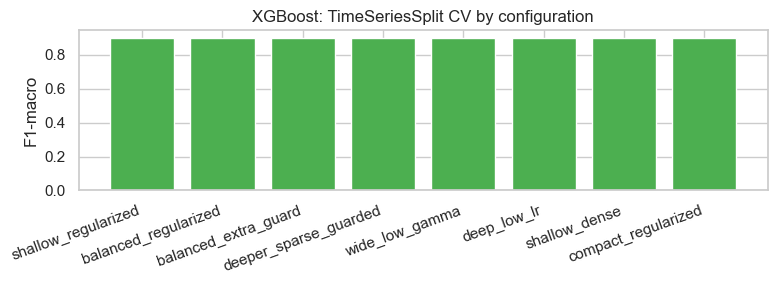


XGBoost Holdout F1-macro: 0.2364

Per-class F1 summary:


,precision,recall,f1-score,support
bloom,0.000000,0.0,0.000000,0.0
vegetative,0.000000,0.0,0.000000,270.0
seedling,0.549296,1.0,0.709091,234.0


              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.55      1.00      0.71       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.18      0.33      0.24       504
weighted avg       0.26      0.46      0.33       504



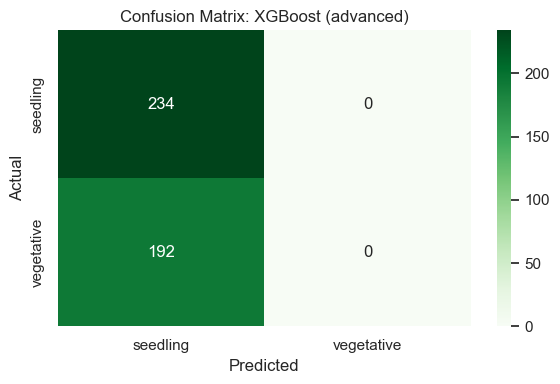

,model,f1_macro,cv_f1_macro
0,XGBoost (advanced),0.236364,0.899394


XGBoost stored in fitted_models.


In [22]:
# Keep the time-aware validation on the original chronological training split.
XGB_TRAINING_MODE = 'weighted'  # 'weighted', 'smote', 'random_over', or 'none'

X_train_cv = X_train.copy()
y_train_cv = y_train.copy()
X_test_cv = X_test.copy()

if XGB_TRAINING_MODE == 'weighted':
    sample_weight = compute_sample_weight(class_weight='balanced', y=y_train_cv.astype(str))
elif XGB_TRAINING_MODE in {'smote', 'random_over'}:
    sample_weight = None
else:
    sample_weight = None

# Final fit may use the resampled set, but CV stays on the chronological original split.
if XGB_TRAINING_MODE in {'smote', 'random_over'} and 'X_train_model' in globals():
    final_train_X = X_train_model.copy()
    final_train_y = y_train_model.copy()
else:
    final_train_X = X_train_cv.copy()
    final_train_y = y_train_cv.copy()

# Encode string labels → integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_cv.astype(str))
y_test_str = y_test.astype(str)

base_xgb_params = dict(
    n_estimators=700,
    eval_metric='mlogloss',
    objective='multi:softprob',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    tree_method='hist',
)

# Broader but still stable XGBoost search.
candidate_configs = [
    {
        'name': 'shallow_regularized',
        'learning_rate': 0.02,
        'max_depth': 3,
        'min_child_weight': 1,
        'subsample': 0.85,
        'colsample_bytree': 0.85,
        'colsample_bynode': 0.85,
        'gamma': 0.0,
        'reg_alpha': 0.0,
        'reg_lambda': 1.5,
    },
    {
        'name': 'balanced_regularized',
        'learning_rate': 0.03,
        'max_depth': 4,
        'min_child_weight': 1,
        'subsample': 0.80,
        'colsample_bytree': 0.80,
        'colsample_bynode': 0.80,
        'gamma': 0.05,
        'reg_alpha': 0.0,
        'reg_lambda': 2.0,
    },
    {
        'name': 'balanced_extra_guard',
        'learning_rate': 0.025,
        'max_depth': 4,
        'min_child_weight': 2,
        'subsample': 0.75,
        'colsample_bytree': 0.75,
        'colsample_bynode': 0.75,
        'gamma': 0.10,
        'reg_alpha': 0.03,
        'reg_lambda': 2.5,
    },
    {
        'name': 'deeper_sparse_guarded',
        'learning_rate': 0.02,
        'max_depth': 5,
        'min_child_weight': 3,
        'subsample': 0.90,
        'colsample_bytree': 0.90,
        'colsample_bynode': 0.90,
        'gamma': 0.15,
        'reg_alpha': 0.05,
        'reg_lambda': 2.5,
    },
    {
        'name': 'wide_low_gamma',
        'learning_rate': 0.04,
        'max_depth': 4,
        'min_child_weight': 5,
        'subsample': 1.0,
        'colsample_bytree': 0.70,
        'colsample_bynode': 0.70,
        'gamma': 0.0,
        'reg_alpha': 0.10,
        'reg_lambda': 1.5,
    },
    {
        'name': 'deep_low_lr',
        'learning_rate': 0.015,
        'max_depth': 6,
        'min_child_weight': 4,
        'subsample': 0.80,
        'colsample_bytree': 0.80,
        'colsample_bynode': 0.80,
        'gamma': 0.20,
        'reg_alpha': 0.10,
        'reg_lambda': 3.0,
    },
    {
        'name': 'shallow_dense',
        'learning_rate': 0.05,
        'max_depth': 2,
        'min_child_weight': 1,
        'subsample': 0.95,
        'colsample_bytree': 0.95,
        'colsample_bynode': 0.95,
        'gamma': 0.0,
        'reg_alpha': 0.0,
        'reg_lambda': 1.0,
    },
    {
        'name': 'compact_regularized',
        'learning_rate': 0.025,
        'max_depth': 3,
        'min_child_weight': 4,
        'subsample': 0.70,
        'colsample_bytree': 0.70,
        'colsample_bynode': 0.70,
        'gamma': 0.10,
        'reg_alpha': 0.05,
        'reg_lambda': 3.0,
    },
]

# TimeSeriesSplit CV / parameter search.
n_splits = min(5, max(2, len(X_train_cv) // 150))
n_splits = min(n_splits, len(X_train_cv) - 1)
n_splits = max(2, n_splits)
tscv = TimeSeriesSplit(n_splits=n_splits)
search_rows = []
best_score = -np.inf
best_params = None
best_config_name = None

for cfg in candidate_configs:
    cfg_name = cfg['name']
    cfg_params = {k: v for k, v in cfg.items() if k != 'name'}
    model_params = dict(base_xgb_params)
    model_params.update(cfg_params)
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_cv), start=1):
        fold_model = xgb.XGBClassifier(**model_params)
        fit_kwargs = {}
        if sample_weight is not None:
            fit_kwargs['sample_weight'] = sample_weight[train_idx]
        fold_model.fit(
            X_train_cv.iloc[train_idx],
            y_train_enc[train_idx],
            eval_set=[(X_train_cv.iloc[val_idx], y_train_enc[val_idx])],
            verbose=False,
            **fit_kwargs,
        )
        fold_pred = fold_model.predict(X_train_cv.iloc[val_idx])
        fold_score = f1_score(y_train_enc[val_idx], fold_pred, average='macro', zero_division=0)
        fold_scores.append(fold_score)

    fold_scores = np.asarray(fold_scores)
    mean_score = float(fold_scores.mean())
    search_rows.append({
        'config': cfg_name,
        'mean_cv_f1': mean_score,
        'std_cv_f1': float(fold_scores.std()),
        'params': str(cfg_params),
    })

    if mean_score > best_score:
        best_score = mean_score
        best_params = model_params
        best_config_name = cfg_name

search_df = pd.DataFrame(search_rows).sort_values('mean_cv_f1', ascending=False).reset_index(drop=True)
print(f'XGBoost training mode: {XGB_TRAINING_MODE}')
print('XGBoost parameter search results:')
print(f'Features entering XGBoost: {X_train_cv.shape[1]}')
display(search_df[['config', 'mean_cv_f1', 'std_cv_f1']])
print(f'Best config: {best_config_name} | Mean CV F1-macro: {best_score:.4f}')

plt.figure(figsize=(8, 3))
plt.bar(search_df['config'], search_df['mean_cv_f1'], color='#4CAF50')
plt.xticks(rotation=20, ha='right')
plt.ylabel('F1-macro')
plt.title('XGBoost: TimeSeriesSplit CV by configuration')
plt.tight_layout()
plt.show()

# Final fit uses the chosen training strategy.
xgb_clf = xgb.XGBClassifier(**best_params)
fit_kwargs = {}
if sample_weight is not None and XGB_TRAINING_MODE == 'weighted':
    fit_kwargs['sample_weight'] = sample_weight
xgb_clf.fit(final_train_X, le.fit_transform(final_train_y.astype(str)), verbose=False, **fit_kwargs)
y_pred_xgb = le.inverse_transform(xgb_clf.predict(X_test_cv))

xgb_f1 = f1_score(y_test_str, y_pred_xgb, average='macro', zero_division=0)
print()
print(f'XGBoost Holdout F1-macro: {xgb_f1:.4f}')
report_df = pd.DataFrame(classification_report(y_test_str, y_pred_xgb, zero_division=0, output_dict=True)).T
per_class_f1 = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')[['precision', 'recall', 'f1-score', 'support']]
per_class_f1 = per_class_f1.sort_values('f1-score')
print()
print('Per-class F1 summary:')
display(per_class_f1)
print(classification_report(y_test_str, y_pred_xgb, zero_division=0))

labels_xgb = sorted(y_test_str.unique())
cm_xgb = confusion_matrix(y_test_str, y_pred_xgb, labels=labels_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=labels_xgb, yticklabels=labels_xgb)
plt.title('Confusion Matrix: XGBoost (advanced)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Add to master results table.
xgb_row = pd.DataFrame([{'model': 'XGBoost (advanced)', 'f1_macro': xgb_f1, 'cv_f1_macro': best_score}])
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    prev_results_df = results_df.copy()
    xgb_prev = prev_results_df[prev_results_df['model'] == 'XGBoost (advanced)']
    if not xgb_prev.empty:
        xgb_row = pd.concat([xgb_prev[['model', 'f1_macro']].assign(cv_f1_macro=best_score), xgb_row], ignore_index=True).tail(1)
    results_df = pd.concat(
        [prev_results_df[prev_results_df['model'] != 'XGBoost (advanced)'], xgb_row],
        ignore_index=True
    ).sort_values('f1_macro', ascending=False).reset_index(drop=True)
else:
    results_df = xgb_row.copy()

display(results_df)

# Store model + label encoder for SHAP.
if 'fitted_models' not in globals():
    fitted_models = {}
fitted_models['XGBoost (advanced)'] = (xgb_clf, le)
print('XGBoost stored in fitted_models.')

## 4.4 Baseline & Ensemble Model Training
**Goal:** Compare the simpler baseline classifiers against a broader set of ensemble and nonlinear models under the same holdout conditions.

**Method:** Train each model on the same time-based split, using the same preprocessing rules, so the differences in score come from the model behavior rather than from a different data pipeline.

**Processes:**
- Fit each baseline on the same train/test split.
- Keep preprocessing consistent across models for fairness.
- Report macro-F1 and confusion matrices so you can see both aggregate quality and class-level mistakes.

**Why this matters:** A broad model sweep is useful only if it is controlled. This section makes sure the comparison is fair enough to tell whether the data itself is hard, not just whether one estimator was tuned better than another.



Logistic Regression (baseline) | CV F1-macro=0.8988 ± 0.2024 | Holdout F1-macro=0.2444
              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.58      0.99      0.73       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.19      0.33      0.24       504
weighted avg       0.27      0.46      0.34       504



/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: F

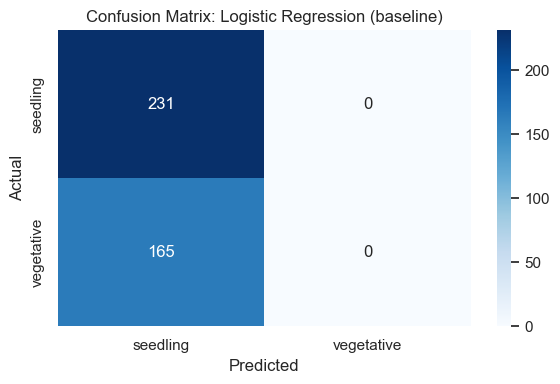


k-NN (tuned) | CV F1-macro=0.8988 ± 0.2024 | Holdout F1-macro=0.3171
              precision    recall  f1-score   support

    seedling       0.46      1.00      0.63       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.23      0.50      0.32       504
weighted avg       0.22      0.46      0.29       504



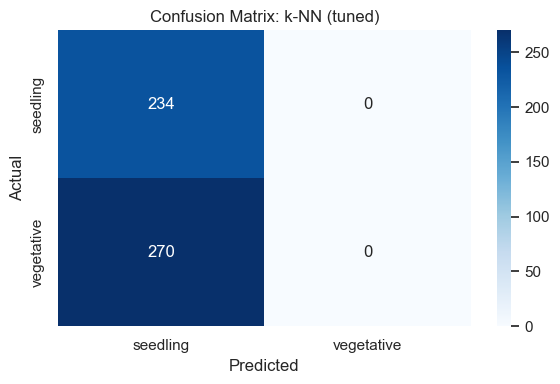


Decision Tree (baseline) | CV F1-macro=0.8994 ± 0.2012 | Holdout F1-macro=0.2081
              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.64      0.61      0.62       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.28       504
   macro avg       0.21      0.20      0.21       504
weighted avg       0.30      0.28      0.29       504



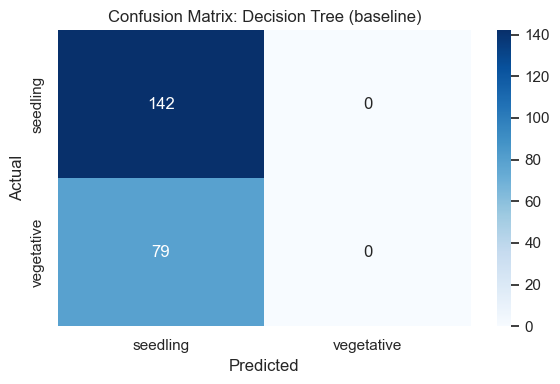


Random Forest (advanced) | CV F1-macro=1.0000 ± 0.0000 | Holdout F1-macro=0.2367
              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.55      1.00      0.71       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.18      0.33      0.24       504
weighted avg       0.26      0.46      0.33       504



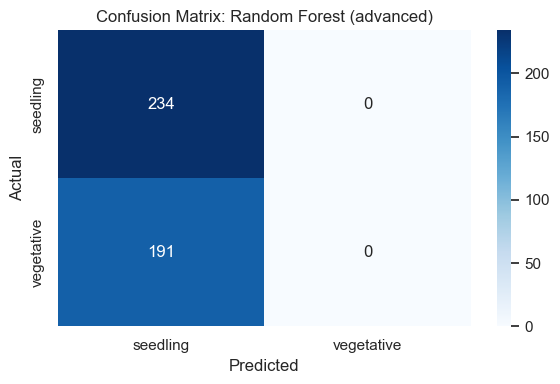


Extra Trees (advanced) | CV F1-macro=1.0000 ± 0.0000 | Holdout F1-macro=0.3171
              precision    recall  f1-score   support

    seedling       0.46      1.00      0.63       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.23      0.50      0.32       504
weighted avg       0.22      0.46      0.29       504



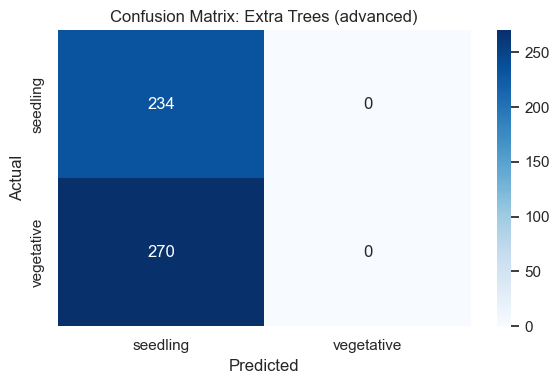


Hist Gradient Boosting | CV F1-macro=0.8994 ± 0.2012 | Holdout F1-macro=0.2371
              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.55      1.00      0.71       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.18      0.33      0.24       504
weighted avg       0.26      0.46      0.33       504



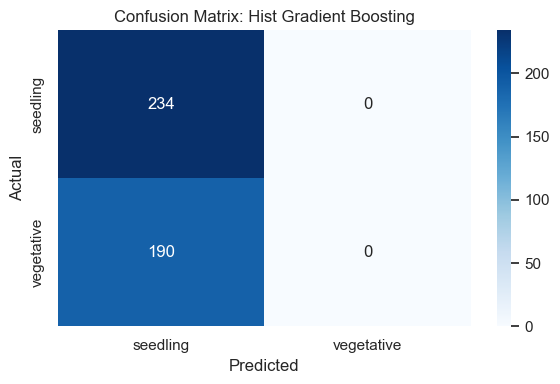


SVC (rbf) | CV F1-macro=1.0000 ± 0.0000 | Holdout F1-macro=0.3171
              precision    recall  f1-score   support

    seedling       0.46      1.00      0.63       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.23      0.50      0.32       504
weighted avg       0.22      0.46      0.29       504



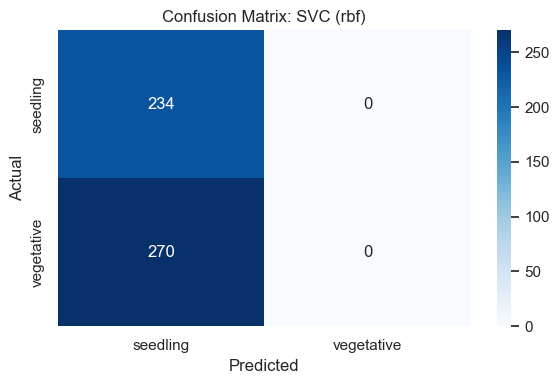


Hierarchical k-NN (2-step) | Holdout F1-macro=0.3171
              precision    recall  f1-score   support

    seedling       0.46      1.00      0.63       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.23      0.50      0.32       504
weighted avg       0.22      0.46      0.29       504



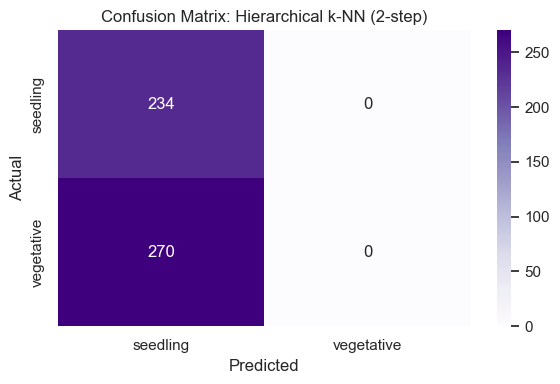


Ordinal HGBR (rounded) | Holdout F1-macro=0.2371
              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.55      1.00      0.71       234
  vegetative       0.00      0.00      0.00       270

    accuracy                           0.46       504
   macro avg       0.18      0.33      0.24       504
weighted avg       0.26      0.46      0.33       504



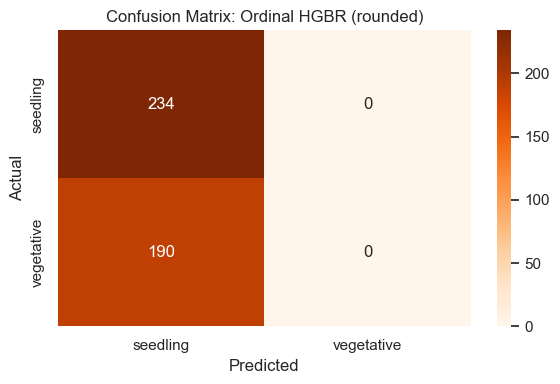

,model,f1_macro,cv_f1_macro,cv_std
0,k-NN (tuned),0.317073,0.898780,0.202439
1,Extra Trees (advanced),0.317073,1.000000,0.000000
2,SVC (rbf),0.317073,1.000000,0.000000
3,Hierarchical k-NN (2-step),0.317073,NaN,NaN
4,Logistic Regression (baseline),0.244444,0.898780,0.202439
5,Hist Gradient Boosting,0.237082,0.899394,0.201212
6,Ordinal HGBR (rounded),0.237082,NaN,NaN
7,Random Forest (advanced),0.236722,1.000000,0.000000
8,XGBoost (advanced),0.236364,0.899394,NaN
9,Decision Tree (baseline),0.208059,0.899394,0.201212


Best model by F1-macro: k-NN (tuned)


In [23]:
model_train_X = X_train_model.copy() if 'X_train_model' in globals() else X_train.copy()
model_train_y = y_train_model.copy() if 'y_train_model' in globals() else y_train.copy()
cv_train_X = X_train_cv.copy() if 'X_train_cv' in globals() else X_train.copy()
cv_train_y = y_train_cv.copy() if 'y_train_cv' in globals() else y_train.copy()

stage_order_map = {'seedling': 0, 'vegetative': 1, 'bloom': 2}
inv_stage_order_map = {v: k for k, v in stage_order_map.items()}


def ts_cv_macro_f1(pipe, X, y):
    n_splits = min(5, max(2, len(X) // 150))
    n_splits = min(n_splits, len(X) - 1)
    n_splits = max(2, n_splits)
    tscv_local = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for train_idx, val_idx in tscv_local.split(X):
        est = clone(pipe)
        est.fit(X.iloc[train_idx], y.iloc[train_idx].astype(str))
        pred = est.predict(X.iloc[val_idx])
        scores.append(f1_score(y.iloc[val_idx].astype(str), pred, average='macro', zero_division=0))
    scores = np.asarray(scores)
    return float(scores.mean()), float(scores.std())


def eval_pipe(name, pipe):
    cv_mean, cv_std = ts_cv_macro_f1(pipe, cv_train_X, cv_train_y)
    pipe.fit(model_train_X, model_train_y.astype(str))
    pred = pipe.predict(X_test)
    holdout_f1 = f1_score(y_test.astype(str), pred, average='macro', zero_division=0)
    results.append({'model': name, 'f1_macro': holdout_f1, 'cv_f1_macro': cv_mean, 'cv_std': cv_std})
    fitted_models[name] = pipe

    print()
    print(f'{name} | CV F1-macro={cv_mean:.4f} ± {cv_std:.4f} | Holdout F1-macro={holdout_f1:.4f}')
    print(classification_report(y_test.astype(str), pred, zero_division=0))

    labels = sorted(y_test.astype(str).unique())
    cm = confusion_matrix(y_test.astype(str), pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


results = []
fitted_models = globals().get('fitted_models', {})

models = {
    'Logistic Regression (baseline)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, class_weight='balanced', C=0.8, n_jobs=-1))
    ]),
    'k-NN (tuned)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5, weights='distance'))
    ]),
    'Decision Tree (baseline)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42))
    ]),
    'Random Forest (advanced)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(n_estimators=600, max_depth=None, class_weight='balanced_subsample', random_state=42, n_jobs=-1))
    ]),
    'Extra Trees (advanced)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', ExtraTreesClassifier(n_estimators=800, class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'Hist Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=300, random_state=42))
    ]),
    'SVC (rbf)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', SVC(C=2.0, gamma='scale', class_weight='balanced'))
    ])
}

for name, pipe in models.items():
    eval_pipe(name, pipe)


def hierarchical_knn_predict(X_train_local, y_train_local, X_test_local):
    y_train_local = y_train_local.astype(str)
    stage1 = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5, weights='distance'))
    ])
    stage1.fit(X_train_local, (y_train_local == 'seedling').astype(int))

    mature_mask = y_train_local != 'seedling'
    stage2 = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5, weights='distance'))
    ])
    stage2.fit(X_train_local.loc[mature_mask], (y_train_local.loc[mature_mask] == 'bloom').astype(int))

    stage1_pred = stage1.predict(X_test_local)
    stage2_pred = stage2.predict(X_test_local)
    final_pred = np.where(stage1_pred == 1, 'seedling', np.where(stage2_pred == 1, 'bloom', 'vegetative'))
    return final_pred, stage1, stage2

hier_pred, hier_stage1, hier_stage2 = hierarchical_knn_predict(model_train_X, model_train_y, X_test)
hier_f1 = f1_score(y_test.astype(str), hier_pred, average='macro', zero_division=0)
results.append({'model': 'Hierarchical k-NN (2-step)', 'f1_macro': hier_f1, 'cv_f1_macro': np.nan, 'cv_std': np.nan})
fitted_models['Hierarchical k-NN (2-step)'] = (hier_stage1, hier_stage2)
print()
print(f'Hierarchical k-NN (2-step) | Holdout F1-macro={hier_f1:.4f}')
print(classification_report(y_test.astype(str), hier_pred, zero_division=0))
labels = sorted(y_test.astype(str).unique())
cm = confusion_matrix(y_test.astype(str), hier_pred, labels=labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Hierarchical k-NN (2-step)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

ordinal_y_train = model_train_y.astype(str).map(stage_order_map).astype(int)
ordinal_y_test = y_test.astype(str).map(stage_order_map).astype(int)
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=300, random_state=42))
])
ordinal_pipe.fit(model_train_X, ordinal_y_train)
ordinal_pred = ordinal_pipe.predict(X_test)
ordinal_pred_idx = np.clip(np.rint(ordinal_pred), 0, 2).astype(int)
ordinal_pred_stage = pd.Series(ordinal_pred_idx).map(inv_stage_order_map).astype(str).to_numpy()
ordinal_f1 = f1_score(y_test.astype(str), ordinal_pred_stage, average='macro', zero_division=0)
results.append({'model': 'Ordinal HGBR (rounded)', 'f1_macro': ordinal_f1, 'cv_f1_macro': np.nan, 'cv_std': np.nan})
fitted_models['Ordinal HGBR (rounded)'] = ordinal_pipe
print()
print(f'Ordinal HGBR (rounded) | Holdout F1-macro={ordinal_f1:.4f}')
print(classification_report(y_test.astype(str), ordinal_pred_stage, zero_division=0))
labels = sorted(y_test.astype(str).unique())
cm = confusion_matrix(y_test.astype(str), ordinal_pred_stage, labels=labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Ordinal HGBR (rounded)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    prev_results_df = results_df.copy()
    xgb_prev = prev_results_df[prev_results_df['model'] == 'XGBoost (advanced)']
    if not xgb_prev.empty and 'XGBoost (advanced)' not in [r['model'] for r in results]:
        results.extend(xgb_prev.to_dict('records'))
results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(results_df)
if not results_df.empty:
    print('Best model by F1-macro:', results_df.iloc[0]['model'])

## 4.5 SHAP Interpretability

**Goal:** Explain which engineered features are driving the best-performing model so the notebook can answer not just "what worked" but also "why it worked."

**Method:** Apply SHAP `TreeExplainer` to the strongest tree-based model and generate both global importance and class-level directionality plots.

**Processes:**
- Sample the test set when needed so the explanation remains fast enough to run interactively.
- Impute missing values before passing data to SHAP.
- Show both summary-style importance and per-class contribution patterns.

**Why this matters:** A model with low or modest performance can still be useful if it is consistent and interpretable. SHAP helps reveal whether the model is learning meaningful sensor relationships or just noise.


Best model: k-NN (tuned) — applying SHAP


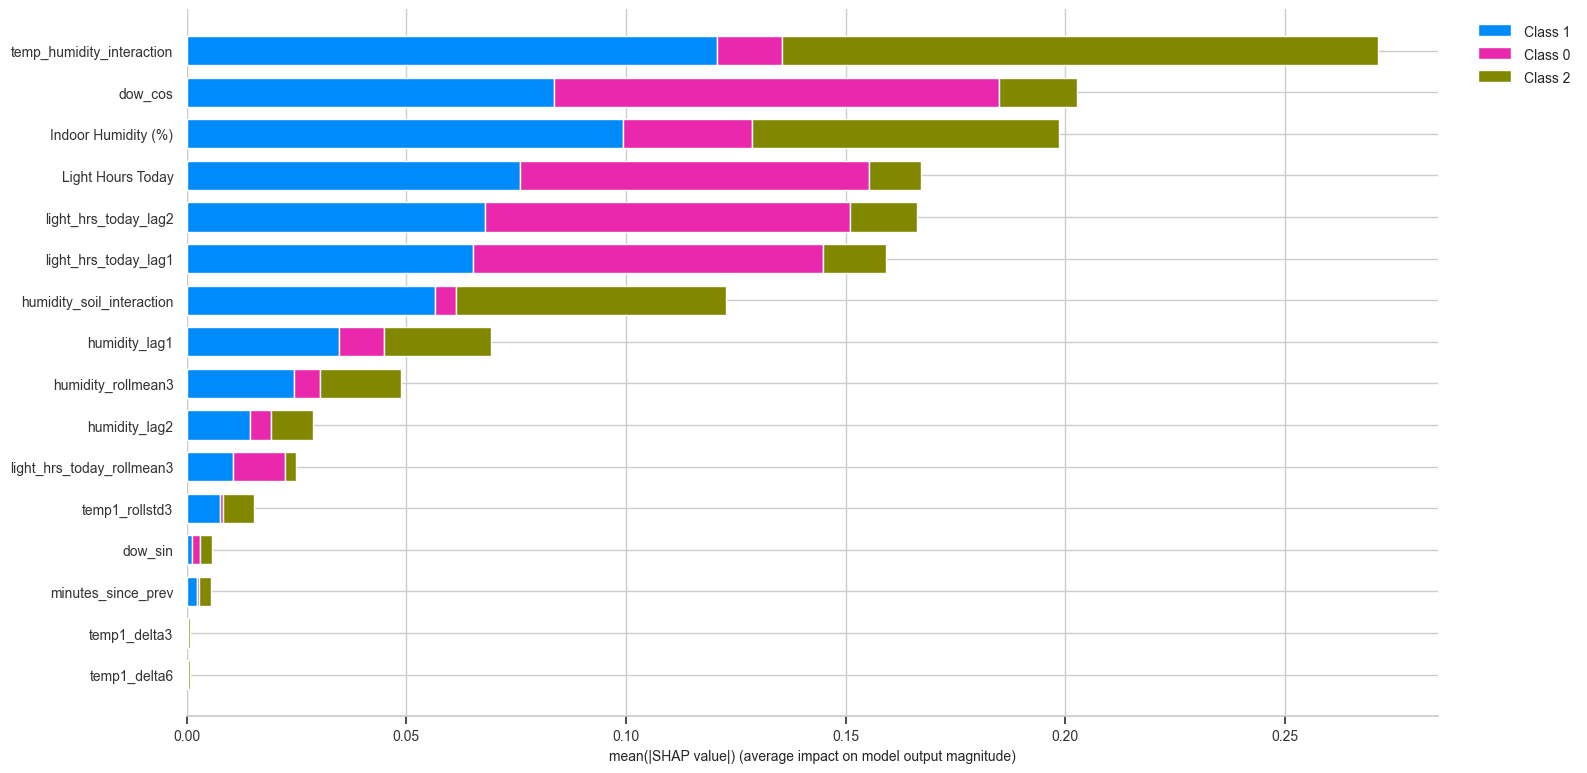

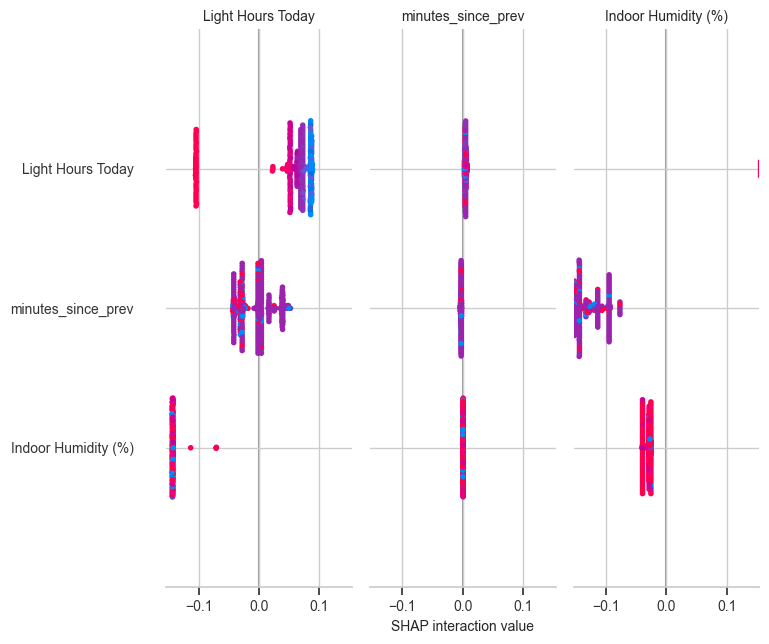

In [24]:
shap_rename = {
    col_temp_in:   "Indoor Temp (°C)",
    col_hum_in:    "Indoor Humidity (%)",
    col_soil:      "Soil Moisture (%)",
    col_light_lux: "Light Intensity (lux)",
    "light_hrs_today":  "Light Hours Today",
    "outdoor_temp":     "Outdoor Temp (°C)",
    "outdoor_humidity": "Outdoor Humidity (%)",
}

def shap_plot(shap_vals, X, plot_type="dot"):
    # Build lookup: first 8 chars of each label -> full label
    all_labels = list(X.columns)
    prefix_map = {lbl[:8]: lbl for lbl in all_labels}

    shap.summary_plot(shap_vals, X, plot_type=plot_type, show=False)
    fig = plt.gcf()
    w, h = fig.get_size_inches()
    fig.set_size_inches(max(w, 16), h)

    # Fix every text object that SHAP truncated with "..." and unify font size
    for obj in fig.findobj(plt.Text):
        t = obj.get_text()
        if t.endswith("..."):
            prefix = t[:-3]
            for key, full in prefix_map.items():
                if full.startswith(prefix):
                    obj.set_text(full)
                    break
        if obj.get_text().strip():
            obj.set_fontsize(10)

    for ax in fig.axes:
        legend = ax.get_legend()
        if legend:
            legend.set_bbox_to_anchor((1.02, 1))
            legend.set_loc("upper left")
    plt.tight_layout()
    plt.show()

if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    best_name = results_df.sort_values("f1_macro", ascending=False).iloc[0]["model"]
else:
    best_name = "Random Forest (advanced)"
print(f"Best model: {best_name} — applying SHAP")

try:
    if best_name == "XGBoost (advanced)" and "XGBoost (advanced)" in fitted_models:
        xgb_model, xgb_imp, xgb_le = fitted_models["XGBoost (advanced)"]
        shap_cols = list(X_train_bal.columns)
        X_test_shap = pd.DataFrame(
            xgb_imp.transform(X_test[shap_cols]),
            columns=shap_cols
        )
        sample_n = min(300, len(X_test_shap))
        X_shap = X_test_shap.sample(n=sample_n, random_state=42) if sample_n > 0 else X_test_shap
        X_shap = X_shap.rename(columns=shap_rename)

        explainer = shap.TreeExplainer(xgb_model)
        shap_vals = explainer.shap_values(X_shap)

        print("SHAP Bar Summary (mean |SHAP| across all classes):")
        shap_plot(shap_vals, X_shap, plot_type="bar")
        print("SHAP Beeswarm (class-level feature impact):")
        shap_plot(shap_vals, X_shap)

    elif "Random Forest (advanced)" in fitted_models:
        rf_pipe = fitted_models["Random Forest (advanced)"]
        rf_imputer = rf_pipe.named_steps["imputer"]
        rf_model   = rf_pipe.named_steps["model"]
        shap_cols = list(X_train_bal.columns)
        X_test_shap = pd.DataFrame(
            rf_imputer.transform(X_test[shap_cols]),
            columns=shap_cols
        )
        sample_n = min(300, len(X_test_shap))
        X_shap = X_test_shap.sample(n=sample_n, random_state=42) if sample_n > 0 else X_test_shap
        X_shap = X_shap.rename(columns=shap_rename)

        explainer = shap.TreeExplainer(rf_model)
        shap_vals = explainer.shap_values(X_shap)
        shap_plot(shap_vals, X_shap, plot_type="bar")
        shap_plot(shap_vals, X_shap)

    else:
        print("No fitted tree model found. Run Sections 5a and 5.3 first.")

except Exception as e:
    print("SHAP error:", e)
    print("Tip: pip install shap")


## 5. Final Model Comparison
**Goal:** Build a presentation-ready comparison of the final model scores so the result is easy to read at a glance.

**Method:** Plot the macro-F1 scores stored in `results_df` and sort them from strongest to weakest.

**Processes:**
- Sort the models by score.
- Plot the macro-F1 values in a compact bar chart.
- Make the advanced pipeline and the simpler baselines easy to compare directly.

**Why this matters:** This is the summary view that shows whether the more sophisticated pipeline actually improved performance or just added complexity.


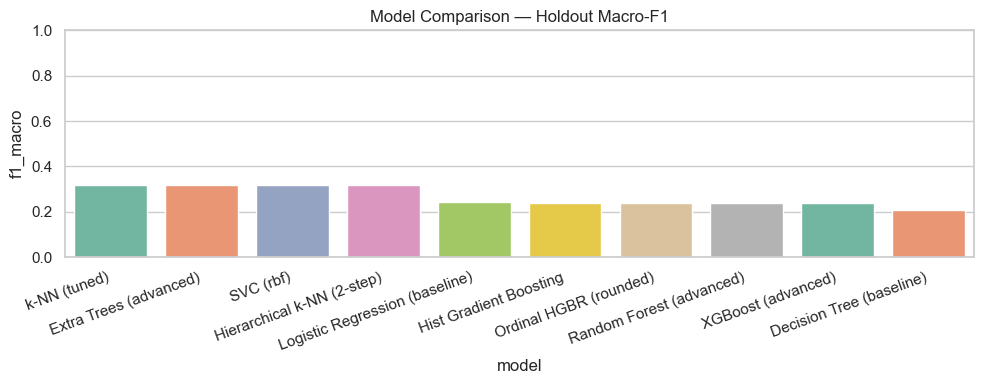

,model,f1_macro,cv_f1_macro,cv_std
0,k-NN (tuned),0.317073,0.898780,0.202439
1,Extra Trees (advanced),0.317073,1.000000,0.000000
2,SVC (rbf),0.317073,1.000000,0.000000
3,Hierarchical k-NN (2-step),0.317073,NaN,NaN
4,Logistic Regression (baseline),0.244444,0.898780,0.202439
5,Hist Gradient Boosting,0.237082,0.899394,0.201212
6,Ordinal HGBR (rounded),0.237082,NaN,NaN
7,Random Forest (advanced),0.236722,1.000000,0.000000
8,XGBoost (advanced),0.236364,0.899394,NaN
9,Decision Tree (baseline),0.208059,0.899394,0.201212


Best model: k-NN (tuned) (F1 = 0.3171)


In [25]:
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    final_df = results_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10, 4))
    sns.barplot(data=final_df, x='model', y='f1_macro', hue='model', palette='Set2', legend=False)
    plt.title('Model Comparison — Holdout Macro-F1')
    plt.ylim(0, 1)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
    display(final_df)
    print('Best model:', final_df.iloc[0]['model'], f"(F1 = {final_df.iloc[0]['f1_macro']:.4f})")
else:
    print('Run Sections 5.3 and 5a first to populate results.')

## 6. Optional Supporting Tasks
These optional tasks reuse the same leakage-safe, time-aware feature set and are included to check whether the engineered signal is also useful for secondary prediction problems beyond stage classification.


### 6.1 Health Score Regression (Optional)
**Goal:** Predict the health score from the engineered sensor features as a secondary check on how much usable signal the dataset contains.

**Method:** Compare a few simple regression baselines on the same chronological split used elsewhere in the notebook.

**Processes:**
- Reuse the leakage-safe temporal features.
- Fit a handful of regression baselines.
- Report MAE and RMSE so the regression task can be compared in a familiar error scale.

**Why this matters:** If the regression task is also weak, that is another hint that the available sensor stream has limited predictive power or inconsistent quality beyond the stage labels alone.


In [26]:
if col_health and col_health in feat.columns:
    reg_df = feat.dropna(subset=['ts']).sort_values('ts').copy()
    temporal_candidates = [
        col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs,
        col_temp_out_feat, col_hum_out_feat,
        'temp_delta', 'minutes_since_prev', 'hour_sin', 'hour_cos', 'daylight_hours',
        f'{col_temp_in}_lag1' if col_temp_in else None,
        f'{col_temp_in}_lag2' if col_temp_in else None,
        f'{col_temp_in}_lag3' if col_temp_in else None,
        f'{col_temp_in}_lag6' if col_temp_in else None,
        f'{col_temp_in}_lag12' if col_temp_in else None,
        f'{col_hum_in}_lag1' if col_hum_in else None,
        f'{col_hum_in}_lag2' if col_hum_in else None,
        f'{col_hum_in}_lag3' if col_hum_in else None,
        f'{col_hum_in}_lag6' if col_hum_in else None,
        f'{col_hum_in}_lag12' if col_hum_in else None,
        f'{col_soil}_lag1' if col_soil else None,
        f'{col_soil}_lag2' if col_soil else None,
        f'{col_soil}_lag3' if col_soil else None,
        f'{col_soil}_lag6' if col_soil else None,
        f'{col_soil}_lag12' if col_soil else None,
        f'{col_light_lux}_lag1' if col_light_lux else None,
        f'{col_light_lux}_lag2' if col_light_lux else None,
        f'{col_light_lux}_lag3' if col_light_lux else None,
        f'{col_light_lux}_lag6' if col_light_lux else None,
        f'{col_light_lux}_lag12' if col_light_lux else None,
        f'{col_light_hrs}_lag1' if col_light_hrs else None,
        f'{col_light_hrs}_lag2' if col_light_hrs else None,
        f'{col_light_hrs}_lag3' if col_light_hrs else None,
        f'{col_light_hrs}_lag6' if col_light_hrs else None,
        f'{col_light_hrs}_lag12' if col_light_hrs else None,
    ]
    X_cols_reg = [c for c in temporal_candidates if c is not None and c in reg_df.columns]

    # Drop all-NaN columns before fitting
    X_cols_reg = [c for c in X_cols_reg if reg_df[c].notna().any()]

    cutoff = pd.Timestamp('2026-04-15')
    split_ts = cutoff if reg_df['ts'].min() < cutoff < reg_df['ts'].max() else reg_df['ts'].quantile(0.8)
    train_mask = reg_df['ts'] < split_ts

    X_train_reg = reg_df.loc[train_mask, X_cols_reg]
    X_test_reg  = reg_df.loc[~train_mask, X_cols_reg]
    y_train_reg = reg_df.loc[train_mask, col_health]
    y_test_reg  = reg_df.loc[~train_mask, col_health]

    reg_models = {
        'Linear Regression':        LinearRegression(),
        'Decision Tree Regressor':  DecisionTreeRegressor(max_depth=6, random_state=42),
        'k-NN Regressor':           KNeighborsRegressor(n_neighbors=7),
    }

    reg_rows = []
    for name, model in reg_models.items():
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('model',   model)
        ])
        pipe.fit(X_train_reg, y_train_reg)
        with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
            pred = pipe.predict(X_test_reg)
        pred = np.nan_to_num(pred, nan=y_train_reg.median(), posinf=y_train_reg.max(), neginf=y_train_reg.min())
        mae  = mean_absolute_error(y_test_reg, pred)
        rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
        reg_rows.append({'model': name, 'mae': mae, 'rmse': rmse})
        print(f'{name}: MAE={mae:.4f}, RMSE={rmse:.4f}')
        
    display(pd.DataFrame(reg_rows).sort_values('mae'))
else:
    print('health_score not found; skip regression task.')


Linear Regression: MAE=8.4646, RMSE=10.0033
Decision Tree Regressor: MAE=9.3054, RMSE=20.5772
k-NN Regressor: MAE=5.5228, RMSE=10.1289


,model,mae,rmse
2,k-NN Regressor,5.522790,10.128910
0,Linear Regression,8.464649,10.003278
1,Decision Tree Regressor,9.305435,20.577179


## 7) References
- Scikit-learn docs: Decision Tree, k-NN, Random Forest, IsolationForest, TimeSeriesSplit
- XGBoost docs: https://xgboost.readthedocs.io
- imbalanced-learn docs (SMOTE): https://imbalanced-learn.org
- SHAP docs: https://shap.readthedocs.io
- Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). *Isolation Forest*. ICDM 2008.
- Chen, T., & Guestrin, J. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016.
- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017.

**Note:** The notebook is now driven by local CSV exports from `data/from_db`, so the live-database path is intentionally not part of the current analysis flow.


## 8. Conclusion

### Outcome
This exhaustive notebook is a stricter and more diagnostic version of `AutoGrow_improved.ipynb`. It keeps the same overall problem framing, but it adds more safeguards and more candidate solutions before deciding what the data can actually support.

### What we tried to improve compared with the improved notebook
- Replaced the live MySQL dependency with local CSV exports so the analysis is reproducible and not blocked by connection limits.
- Added stage-transition filtering so the model is trained less on ambiguous boundary rows.
- Added a mutual-information feature-selection sweep to reduce weak or redundant engineered features.
- Compared multiple imbalance strategies instead of relying on a single resampling choice.
- Added time-aware cross-validation for a more honest evaluation of each model.
- Expanded the model zoo to include logistic regression, tuned k-NN, decision tree, random forest, extra trees, hist-gradient boosting, SVC, a hierarchical two-step classifier, and an ordinal regression path.
- Added SHAP interpretation and a secondary health-score regression task to check whether the signal generalizes beyond the main classification target.

### What the results suggest
If the exhaustive notebook still gives only modest macro-F1 scores after all of those changes, that weak performance is less likely to be caused by one bad model choice and more likely to be caused by the dataset itself. The strongest evidence points to a combination of low signal-to-noise ratio, stage-label overlap, limited sample size, and possible label inconsistency around stage transitions.

### Can we now assume the low performance came from low data quality?
Not as a hard proof, but yes as a reasonable working hypothesis.

What the notebook can support is this: when we make the pipeline stricter, more leakage-safe, and more expressive, the scores do not jump dramatically. That means the problem is probably not just "we picked the wrong classifier." It is more likely that the available data does not cleanly separate the stages, or that some labels and sensor readings are noisy enough to cap performance.

### Practical conclusion
So the right conclusion is not "the data is definitely bad," but rather:
- the data quality and label quality are likely major limiting factors,
- model choice alone is unlikely to solve the problem,
- and the next improvement should focus on better labels, more cycles of data, cleaner sensors, or a sequence-aware / ordinal modeling approach that matches the growth process more naturally.

### Next step
Use the exhaustive notebook as the stronger diagnostic baseline, then decide whether the next iteration should focus on data collection, label cleanup, or a different model family entirely.
